# Lab 8 - DuckDB: viajes de taxi de Nueva York


Repositorio del equipo: https://github.com/erickguerra2/duckdb, fork de https://github.com/menene/duckdb


In [1]:
import os
import sys
import json
import time
import shutil
import platform
import subprocess
import textwrap
import importlib.metadata as md
from pathlib import Path

import duckdb
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Image

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ / "scripts"))
import taxi_db

DIR_SQL = Path("sql")
DIR_FIG = Path("docs/figuras")
DIR_FIG.mkdir(parents=True, exist_ok=True)
DB_TAXI = Path("data/processed/taxi.duckdb")
METABASE = os.environ.get("MB_URL", "http://metabase:3000")

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Raíz del proyecto:", RAIZ)

Raíz del proyecto: /workspace


In [2]:
# Paleta validada
COLOR_TAXI = {"yellow": "#eda100", "green": "#008300"}
COLOR_ANIO = {"2024": "#2a78d6", "2025": "#eb6834", "2026": "#1baf7a"}
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
TINTA, TINTA_2, REJILLA = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "regular",
    "axes.edgecolor": REJILLA, "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "lines.linewidth": 2, "legend.frameon": False,
})
miles = FuncFormatter(lambda x, _: f"{x:,.0f}")


def guardar(fig, nombre):
    fig.savefig(DIR_FIG / f"{nombre}.png")
    plt.show()

In [3]:
CATALOGO = []
FUENTE = {"texto": ""}
con = duckdb.connect()
con.execute(f"SET memory_limit = '{taxi_db.MEMORIA}'")


def consulta(nombre, objetivo, sql, fuente=None, conexion=None, mostrar=True):
    conexion = conexion or con
    fuente = fuente or FUENTE["texto"]
    sql = textwrap.dedent(sql).strip().rstrip(";")
    ruta = DIR_SQL / f"{nombre}.sql"
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ruta.write_text(f"-- Objetivo: {objetivo}\n-- Fuente: {fuente}\n{sql};\n", encoding="utf-8")
    inicio = time.perf_counter()
    df = conexion.sql(sql).df()
    segundos = time.perf_counter() - inicio
    CATALOGO.append({"consulta": nombre, "objetivo": objetivo, "fuente": fuente,
                     "filas": len(df), "segundos": round(segundos, 2)})
    print(f"[{ruta}]  {len(df)} filas en {segundos:.2f} s")
    print(f"Objetivo: {objetivo}")
    print(f"Fuente: {fuente}")
    if mostrar:
        display(df)
    return df


def usar_anios(anios):
    taxi_db.crear_vistas(con, anios)
    FUENTE["texto"] = "vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{" + ",".join(map(str, anios)) + "}/*.parquet"
    print("Vistas creadas para", anios)


def descargar(*anios):
    args = [sys.executable, "scripts/download_data.py"] + (["--anio", *map(str, anios)] if anios else [])
    r = subprocess.run(args, capture_output=True, text=True)
    lineas = r.stdout.splitlines()
    omitidos = sum("ya existe" in l for l in lineas)
    nuevos = sum("listo (" in l for l in lineas)
    print(f"Archivos omitidos por existir: {omitidos} | descargados ahora: {nuevos}")
    print("\n".join(lineas[lineas.index("RESUMEN") - 1:]))
    return pd.read_csv("docs/manifest_descargas.csv")

## Ejercicio 1. Preparación del ambiente

### 1.1 y 1.2 Fork, clonación y arranque

El repositorio del docente se bifurcó en https://github.com/erickguerra2/duckdb 

### Estructura del proyecto

| Directorio o archivo | Propósito |
|---|---|
| data/raw | Archivos Parquet tal como los publica la TLC, organizados en tipo y año. Nunca se modifican |
| data/processed | Productos derivados: la base taxi.duckdb materializada y archivos temporales del benchmark |
| notebooks | Este notebook con el análisis, que documenta cada consulta y su interpretación |
| scripts | Código reutilizable: descarga, vistas y materialización, benchmark y publicación del tablero |
| sql | Todas las consultas SQL versionadas: vistas, consultas de cada ejercicio, benchmark e indicadores |
| docs | Evidencia generada: manifiesto de descarga, bitácoras, resultados del benchmark, figuras y capturas del tablero |
| Dockerfile | Imagen del ambiente de análisis con Python y las librerías fijadas en requirements.txt |
| metabase.Dockerfile | Imagen de Metabase con el driver de DuckDB en versiones alineadas |
| docker-compose.yml | Orquesta ambos servicios, puertos y volúmenes |
| README.md | Instrucciones para reproducir todo el trabajo |

La separación entre raw y processed permite regenerar cualquier producto desde los datos originales, y data está excluida de Git por .gitignore.

### 1.3 y 1.4 Verificación de servicios y herramientas disponibles

In [4]:
print("Python", platform.python_version(), "|", platform.platform())
for paquete in ["duckdb", "pandas", "pyarrow", "matplotlib", "requests", "jupyterlab", "nbconvert"]:
    print(f"  {paquete:12} {md.version(paquete)}")
print("DuckDB SQL:", duckdb.sql("SELECT version()").fetchone()[0])
print("curl:", shutil.which("curl"))

salud = requests.get(f"{METABASE}/api/health", timeout=10).json()
print("Metabase /api/health:", salud)
version_mb = requests.get(f"{METABASE}/api/session/properties", timeout=10).json()["version"]["tag"]
print("Metabase versión:", version_mb)
print("Driver DuckDB en Metabase:", "duckdb" in requests.get(f"{METABASE}/api/session/properties").json()["engines"])

for carpeta in ["data/raw", "data/processed", "notebooks", "scripts", "sql", "docs"]:
    print(f"  montaje {carpeta:15} existe={Path(carpeta).exists()}")

Python 3.11.14 | Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.41
  duckdb       1.5.5
  pandas       3.0.6
  pyarrow      25.0.1
  matplotlib   3.11.2
  requests     2.34.2
  jupyterlab   4.6.4
  nbconvert    7.17.1
DuckDB SQL: v1.5.5
curl: /usr/bin/curl
Metabase /api/health: {'status': 'ok'}


Metabase versión: v0.63.19


Driver DuckDB en Metabase: True
  montaje data/raw        existe=True
  montaje data/processed  existe=True
  montaje notebooks       existe=True
  montaje scripts         existe=True
  montaje sql             existe=True
  montaje docs            existe=True


Herramientas disponibles dentro del ambiente:

| Herramienta | Uso en el laboratorio |
|---|---|
| Python 3.11 | Lenguaje de los scripts y del notebook |
| DuckDB 1.5.5 | Motor analítico en proceso: consulta Parquet y materializa tablas |
| pandas y pyarrow | Reciben resultados de DuckDB y leen metadatos Parquet sin cargar los datos |
| matplotlib | Gráficos del notebook |
| requests y curl | Descarga desde la TLC y uso de la API de Metabase |
| JupyterLab y nbconvert | Edición y ejecución reproducible del notebook |
| Metabase con driver DuckDB | Herramienta de tableros proporcionada, conectada a taxi.duckdb en modo solo lectura |

Ambos servicios responden: JupyterLab sirve este notebook y Metabase devuelve status ok con el driver de DuckDB registrado.

### 1.5 Procedimiento documentado

El procedimiento para levantar el ambiente quedó en la sección Como levantar el ambiente del README.md.

### 1.6 Por qué un ambiente reproducible

Un análisis de datos depende de versiones exactas: un cambio de DuckDB puede alterar el formato del archivo .duckdb, la forma de inferir tipos o el resultado de funciones como quantile_cont, y Metabase solo abre bases creadas con la misma versión de DuckDB que su driver. Con Docker cualquier integrante o el docente obtiene las mismas versiones de Python, librerías y servicios con un solo comando, sin depender de lo instalado en cada computadora. Eso hace que los resultados se puedan verificar, que los errores se puedan reproducir y que el trabajo siga funcionando meses después. También aísla dependencias pesadas como Java para Metabase y deja documentada la infraestructura como código.

## Ejercicio 2. Sistema de descarga

### 2.1 Análisis del script original

El script scripts/download_data.py entregado ya resolvía bien varias cosas: consultaba con HEAD si un archivo estaba publicado, descargaba por bloques sobre un archivo temporal .part con reintentos y omitía los archivos existentes. Sus limitaciones eran:

- El año estaba fijo en la constante ANIO = 2026 y se usaba dentro de construir_nombre, construir_url y ruta_destino, así que agregar 2024 o 2025 obligaba a editar el código.
- No había un parámetro de línea de comandos para elegir años.
- Recorría siempre los 12 meses, incluso meses futuros que no pueden existir.
- No verificaba que el tamaño descargado coincidiera con el publicado, por lo que un corte de red podía dejar un archivo truncado que después se consideraría existente.
- No había forma de comprobar al final que el conjunto descargado estuviera completo ni registro de lo obtenido.
- No descargaba el catálogo de zonas, necesario para traducir PULocationID y DOLocationID a nombres.

### 2.2 a 2.4 Cambios realizados

- Las funciones reciben el año como parámetro y se agregó --anio, que acepta uno o varios años. Por defecto descarga 2024, 2025 y 2026.
- meses_posibles limita el año en curso al mes actual.
- La descarga compara los bytes escritos con Content-Length y descarta el archivo si no coinciden.
- Se agregó --verificar para validar sin descargar.
- Al terminar, validar_local revisa cada archivo: tamaño local contra tamaño publicado, lectura de los metadatos Parquet con pyarrow, número de filas y columnas, y huecos de meses intermedios. El resultado se guarda en docs/manifest_descargas.csv.
- Se descarga una sola vez data/raw/zones/taxi_zone_lookup.csv.
- Se conservó la estructura data/raw/tipo/año/nombre-original.parquet y la regla de no volver a descargar archivos existentes.

### 2.5 Ejecución

La primera ejecución real quedó registrada en docs/logs/descarga_2026.txt. Aquí se muestra ese registro y luego se ejecuta otra vez el script para comprobar que no vuelve a descargar nada.

In [5]:
primera = Path("docs/logs/descarga_2026.txt").read_text().splitlines()
print("\n".join(primera[:12] + ["  ..."] + primera[-16:]))


=== YELLOW 2026 ===
  2026-01  descargando...
  2026-01  listo (61.2 MiB) -> data/raw/yellow/2026/yellow_tripdata_2026-01.parquet
  2026-02  descargando...
  2026-02  listo (56.0 MiB) -> data/raw/yellow/2026/yellow_tripdata_2026-02.parquet
  2026-03  descargando...
  2026-03  listo (64.7 MiB) -> data/raw/yellow/2026/yellow_tripdata_2026-03.parquet
  2026-04  descargando...
  2026-04  listo (61.8 MiB) -> data/raw/yellow/2026/yellow_tripdata_2026-04.parquet
  2026-05  descargando...
  2026-05  listo (66.5 MiB) -> data/raw/yellow/2026/yellow_tripdata_2026-05.parquet
  ...
Validando archivos locales...

RESUMEN
  anios         : 2026
  descargados   : 16
  ya existian   : 0
  no publicados : 4
      yellow 2026-09, yellow 2026-10, green 2026-09, green 2026-10
  fallidos      : 0
  archivos locales validados : 16
  registros totales          : 30,040,469
  archivos con problemas     : 0
  manifiesto                 : docs/manifest_descargas.csv


In [6]:
manifiesto = descargar(2026)

Archivos omitidos por existir: 17 | descargados ahora: 0
RESUMEN
  anios         : 2026
  descargados   : 0
  ya existian   : 16
  no publicados : 4
      yellow 2026-09, yellow 2026-10, green 2026-09, green 2026-10
  fallidos      : 0
  archivos locales validados : 16
  registros totales          : 30,040,469
  archivos con problemas     : 0
  manifiesto                 : docs/manifest_descargas.csv


In [7]:
resumen_2026 = (manifiesto.groupby(["tipo", "anio"])
                .agg(archivos=("mes", "count"), primer_mes=("mes", "min"), ultimo_mes=("mes", "max"),
                     registros=("registros", "sum"), mib=("bytes_local", lambda b: b.sum() / 2**20),
                     tamanio_ok=("tamanio_ok", "all"), legibles=("parquet_legible", "all"))
                .reset_index())
display(resumen_2026)

,tipo,anio,archivos,primer_mes,ultimo_mes,registros,mib,tamanio_ok,legibles
0,green,2026,8,1,8,337114,7.89,True,True
1,yellow,2026,8,1,8,29703355,487.76,True,True


### 2.6 Documentación de los cambios

Los cambios están descritos en 2.2 a 2.4, en el docstring del script y en la sección Como descargar los datos del README.

### 2.7 Cómo se determinó que el conjunto está completo

Se usaron cuatro criterios independientes:

1. Publicación: para cada mes posible el script consulta al servidor de la TLC. En 2026 están publicados enero a agosto para ambos tipos; septiembre y octubre responden como no publicados porque la TLC publica con unas semanas de atraso. Ningún mes publicado quedó sin descargar.
2. Continuidad: no hay huecos de meses intermedios; los 8 meses son consecutivos para cada tipo.
3. Integridad de bytes: el tamaño local coincide exactamente con el Content-Length del servidor en los 16 archivos.
4. Integridad del formato: los 16 archivos abren como Parquet válido y reportan filas y columnas desde sus metadatos, sin errores.

Con eso hay 16 archivos y 30,040,469 registros de 2026. En el ejercicio 3 se vuelve a contar con DuckDB y el total coincide con los metadatos.

## Ejercicio 3. Consultas directas sobre archivos Parquet

En este ejercicio no se crea ninguna tabla ni vista: cada consulta usa read_parquet, glob, parquet_schema o parquet_metadata directamente sobre los archivos de 2026. Cada consulta se guarda automáticamente en sql/ejercicio3 con su objetivo y su fuente, y su resultado se muestra debajo.

In [8]:
YELLOW_26 = "data/raw/yellow/2026/*.parquet"
GREEN_26 = "data/raw/green/2026/*.parquet"
TODOS_26 = "data/raw/*/2026/*.parquet"
FUENTE["texto"] = "data/raw/{yellow,green}/2026/*.parquet"

### 3.1 Cantidad de archivos

In [9]:
archivos = consulta("ejercicio3/01_cantidad_archivos", "Contar los archivos Parquet de 2026 por tipo de taxi", f"""
    SELECT split_part(file, '/', 3) AS taxi,
           count(*) AS archivos,
           min(regexp_extract(file, '(\\d{{4}}-\\d{{2}})', 1)) AS primer_mes,
           max(regexp_extract(file, '(\\d{{4}}-\\d{{2}})', 1)) AS ultimo_mes
    FROM glob('{TODOS_26}')
    GROUP BY taxi
    ORDER BY taxi
""")

[sql/ejercicio3/01_cantidad_archivos.sql]  2 filas en 0.05 s
Objetivo: Contar los archivos Parquet de 2026 por tipo de taxi
Fuente: data/raw/{yellow,green}/2026/*.parquet


,taxi,archivos,primer_mes,ultimo_mes
0,green,8,2026-01,2026-08
1,yellow,8,2026-01,2026-08


### 3.2 Cantidad de registros

In [10]:
registros = consulta("ejercicio3/02_cantidad_registros", "Contar registros leyendo los archivos completos", f"""
    SELECT 'yellow' AS taxi, count(*) AS registros FROM read_parquet('{YELLOW_26}', union_by_name = true)
    UNION ALL
    SELECT 'green', count(*) FROM read_parquet('{GREEN_26}', union_by_name = true)
""")
metadatos = consulta("ejercicio3/03_registros_metadatos", "Contar registros solo desde los metadatos Parquet", f"""
    SELECT split_part(file_name, '/', 3) AS taxi,
           count(DISTINCT file_name) AS archivos,
           sum(row_group_num_rows) FILTER (WHERE column_id = 0) AS registros,
           count(*) FILTER (WHERE column_id = 0) AS row_groups
    FROM parquet_metadata('{TODOS_26}')
    GROUP BY taxi
    ORDER BY taxi
""")
print("Total 2026:", f"{registros.registros.sum():,}", "| coincide con manifiesto:",
      registros.registros.sum() == manifiesto.registros.sum())

[sql/ejercicio3/02_cantidad_registros.sql]  2 filas en 0.09 s
Objetivo: Contar registros leyendo los archivos completos
Fuente: data/raw/{yellow,green}/2026/*.parquet


,taxi,registros
0,yellow,29703355
1,green,337114


[sql/ejercicio3/03_registros_metadatos.sql]  2 filas en 0.05 s
Objetivo: Contar registros solo desde los metadatos Parquet
Fuente: data/raw/{yellow,green}/2026/*.parquet


,taxi,archivos,registros,row_groups
0,green,8,"337,114.00",8
1,yellow,8,"29,703,355.00",32


Total 2026: 30,040,469 | coincide con manifiesto: True


### 3.3 y 3.4 Columnas y tipos de datos

In [11]:
esquema = consulta("ejercicio3/04_columnas_por_archivo", "Columnas y tipo físico presentes en cada archivo", f"""
    SELECT split_part(file_name, '/', 3) AS taxi,
           name AS columna,
           type AS tipo_fisico,
           logical_type,
           count(DISTINCT file_name) AS archivos_con_columna,
           min(regexp_extract(file_name, '(\\d{{4}}-\\d{{2}})', 1)) AS desde
    FROM parquet_schema('{TODOS_26}')
    WHERE name <> 'schema'
    GROUP BY ALL
    ORDER BY taxi, columna
""", mostrar=False)
display(esquema.pivot_table(index="columna", columns="taxi", values="archivos_con_columna", fill_value=0))

[sql/ejercicio3/04_columnas_por_archivo.sql]  43 filas en 0.05 s
Objetivo: Columnas y tipo físico presentes en cada archivo
Fuente: data/raw/{yellow,green}/2026/*.parquet


taxi,green,yellow
columna,,
Airport_fee,0.00,8.00
DOLocationID,8.00,8.00
PULocationID,8.00,8.00
RatecodeID,8.00,8.00
VendorID,8.00,8.00
cbd_congestion_fee,8.00,8.00
congestion_surcharge,8.00,8.00
ehail_fee,8.00,0.00
extra,8.00,8.00


In [12]:
tipos_y = consulta("ejercicio3/05_tipos_yellow", "Tipos lógicos que DuckDB asigna a las columnas de taxis amarillos",
                   f"DESCRIBE SELECT * FROM read_parquet('{YELLOW_26}', union_by_name = true)", mostrar=False)
tipos_g = consulta("ejercicio3/06_tipos_green", "Tipos lógicos que DuckDB asigna a las columnas de taxis verdes",
                   f"DESCRIBE SELECT * FROM read_parquet('{GREEN_26}', union_by_name = true)", mostrar=False)
tipos = (tipos_y[["column_name", "column_type"]].rename(columns={"column_type": "yellow"})
         .merge(tipos_g[["column_name", "column_type"]].rename(columns={"column_type": "green"}),
                on="column_name", how="outer"))
display(tipos)

[sql/ejercicio3/05_tipos_yellow.sql]  21 filas en 0.04 s
Objetivo: Tipos lógicos que DuckDB asigna a las columnas de taxis amarillos
Fuente: data/raw/{yellow,green}/2026/*.parquet


[sql/ejercicio3/06_tipos_green.sql]  22 filas en 0.04 s
Objetivo: Tipos lógicos que DuckDB asigna a las columnas de taxis verdes
Fuente: data/raw/{yellow,green}/2026/*.parquet


,column_name,yellow,green
0,Airport_fee,DOUBLE,NaN
1,DOLocationID,INTEGER,INTEGER
2,PULocationID,INTEGER,INTEGER
3,RatecodeID,BIGINT,BIGINT
4,VendorID,INTEGER,INTEGER
5,cbd_congestion_fee,DOUBLE,DOUBLE
6,congestion_surcharge,DOUBLE,DOUBLE
7,ehail_fee,NaN,DOUBLE
8,extra,DOUBLE,DOUBLE
9,fare_amount,DOUBLE,DOUBLE


Los amarillos tienen 21 columnas y los verdes 22. Las diferencias de esquema son:

- Las fechas se llaman tpep_pickup_datetime y tpep_dropoff_datetime en amarillos, y lpep en verdes.
- Solo los amarillos tienen Airport_fee; solo los verdes tienen ehail_fee y trip_type.
- request_source aparece solo desde junio de 2026, en 3 de los 8 archivos de cada tipo. Es una columna nueva que no está en el diccionario de datos publicado por la TLC.
- passenger_count, RatecodeID y payment_type vienen como BIGINT aunque son códigos pequeños; las zonas son INTEGER y los montos DOUBLE.

Decisión: para analizar ambos tipos juntos se necesita una vista que renombre las fechas, homologue tipos y tolere columnas ausentes. Se construye en el ejercicio 4.

### 3.5 Muestra de registros

In [13]:
muestra = consulta("ejercicio3/07_muestra_yellow", "Muestra reproducible de viajes amarillos", f"""
    SELECT * FROM read_parquet('{YELLOW_26}', union_by_name = true)
    USING SAMPLE reservoir(5 ROWS) REPEATABLE (42)
""")
muestra_g = consulta("ejercicio3/08_muestra_green", "Muestra reproducible de viajes verdes", f"""
    SELECT * FROM read_parquet('{GREEN_26}', union_by_name = true)
    USING SAMPLE reservoir(5 ROWS) REPEATABLE (42)
""")

[sql/ejercicio3/07_muestra_yellow.sql]  5 filas en 0.21 s
Objetivo: Muestra reproducible de viajes amarillos
Fuente: data/raw/{yellow,green}/2026/*.parquet


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,request_source
0,1,2026-01-01 00:34:45,2026-01-01 00:40:15,4,0.90,1,N,262,141,1,7.90,3.50,0.50,3.20,0.00,1.00,16.10,2.50,0.00,0.00,None
1,1,2026-01-01 00:06:07,2026-01-01 00:20:20,2,1.90,1,N,231,90,1,14.20,4.25,0.50,3.95,0.00,1.00,23.90,2.50,0.00,0.75,None
2,2,2026-01-01 03:15:42,2026-01-01 03:20:33,1,1.15,1,N,263,140,1,7.20,1.00,0.50,2.44,0.00,1.00,14.64,2.50,0.00,0.00,None
3,2,2026-01-01 04:25:35,2026-01-01 04:38:18,1,3.69,1,N,107,143,1,17.70,1.00,0.50,4.69,0.00,1.00,28.14,2.50,0.00,0.75,None
4,2,2026-01-01 06:33:56,2026-01-01 06:55:37,2,10.27,2,N,68,138,2,70.00,0.00,0.50,0.00,6.94,1.00,81.69,2.50,0.00,0.75,None


[sql/ejercicio3/08_muestra_green.sql]  5 filas en 0.11 s
Objetivo: Muestra reproducible de viajes verdes
Fuente: data/raw/{yellow,green}/2026/*.parquet


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,request_source
0,2,2026-01-02 05:43:34,2026-01-02 05:44:09,N,5,34,34,2,0.40,70.00,0.00,0.00,14.20,0.00,NaN,1.00,85.20,1,2,0.00,0.00,None
1,2,2026-01-02 21:02:00,2026-01-02 21:07:42,N,1,74,41,1,1.17,7.90,1.00,0.50,2.08,0.00,NaN,1.00,12.48,1,1,0.00,0.00,None
2,1,2026-01-14 21:03:03,2026-01-14 21:06:16,N,1,181,65,1,0.60,5.80,1.00,1.50,0.00,0.00,NaN,1.00,8.30,2,1,0.00,0.00,None
3,2,2026-01-16 19:11:20,2026-01-16 19:29:44,N,1,74,151,1,2.33,17.70,2.50,0.50,4.34,0.00,NaN,1.00,26.04,1,1,0.00,0.00,None
4,2,2026-01-19 02:15:45,2026-01-19 02:20:57,N,1,95,102,1,1.35,8.60,1.00,0.50,1.00,0.00,NaN,1.00,12.10,1,1,0.00,0.00,None


### 3.6 Problemas de calidad

Primero se usa SUMMARIZE, que calcula en una sola pasada mínimo, máximo, valores distintos aproximados, promedio, cuartiles y porcentaje de nulos de cada columna.

In [14]:
perfil_y = consulta("ejercicio3/09_perfil_yellow", "Perfil estadístico de todas las columnas amarillas",
                    f"SUMMARIZE SELECT * FROM read_parquet('{YELLOW_26}', union_by_name = true)", mostrar=False)
display(perfil_y[["column_name", "min", "max", "approx_unique", "avg", "q50", "null_percentage"]])

[sql/ejercicio3/09_perfil_yellow.sql]  21 filas en 11.44 s
Objetivo: Perfil estadístico de todas las columnas amarillas
Fuente: data/raw/{yellow,green}/2026/*.parquet


,column_name,min,max,approx_unique,avg,q50,null_percentage
0,VendorID,1,7,4,1.885739809526567,2,0.00
1,tpep_pickup_datetime,2001-01-01 09:23:58,2026-08-31 23:59:59,16867928,2026-04-30 15:29:29.519432,2026-04-30 23:13:00.550942,0.00
2,tpep_dropoff_datetime,2001-01-01 16:09:38,2026-09-01 20:16:00,16587125,2026-04-30 15:47:08.186216,2026-04-30 19:30:25.715078,0.00
3,passenger_count,0,9,11,1.2494318488564,1,25.98
4,trip_distance,0.0,328522.2,7217,5.552940149689086,1.8562155905933497,0.00
5,RatecodeID,1,99,7,4.527471444398553,1,25.98
6,store_and_fwd_flag,N,Y,2,NaN,NaN,25.98
7,PULocationID,1,265,290,161.57793013617484,161,0.00
8,DOLocationID,1,265,298,161.05139342003622,162,0.00
9,payment_type,0,5,6,0.8621735154160195,1,0.00


In [15]:
perfil_g = consulta("ejercicio3/10_perfil_green", "Perfil estadístico de todas las columnas verdes",
                    f"SUMMARIZE SELECT * FROM read_parquet('{GREEN_26}', union_by_name = true)", mostrar=False)
display(perfil_g[["column_name", "min", "max", "approx_unique", "avg", "q50", "null_percentage"]])

[sql/ejercicio3/10_perfil_green.sql]  22 filas en 0.33 s
Objetivo: Perfil estadístico de todas las columnas verdes
Fuente: data/raw/{yellow,green}/2026/*.parquet


,column_name,min,max,approx_unique,avg,q50,null_percentage
0,VendorID,1,6,3,2.328351833504393,2,0.00
1,lpep_pickup_datetime,2008-12-31 17:35:31,2026-08-31 23:58:28,332702,2026-05-02 13:25:51.096427,2026-05-03 11:25:12.16329,0.00
2,lpep_dropoff_datetime,2008-12-31 23:16:26,2026-09-02 09:39:37,396286,2026-05-02 13:46:38.833759,2026-05-03 22:53:23.532589,0.00
3,store_and_fwd_flag,N,Y,2,NaN,NaN,14.47
4,RatecodeID,1,99,7,1.2549672434183374,1,14.47
5,PULocationID,1,265,263,97.32761024460568,75,0.00
6,DOLocationID,1,265,266,142.8768458147689,140,0.00
7,passenger_count,0,9,11,1.3006461144694266,1,14.47
8,trip_distance,0.0,179830.92,2472,13.349507644298379,2.0659214503119703,0.00
9,fare_amount,-500.0,1676.7,4808,17.014101995170655,13.164726506912354,0.00


In [16]:
fechas = consulta("ejercicio3/11_fechas_fuera_de_archivo", "Viajes cuya fecha no corresponde al mes del archivo", f"""
    SELECT split_part(filename, '/', 3) AS taxi,
           count(*) AS registros,
           count_if(strftime(coalesce(tpep_pickup_datetime, lpep_pickup_datetime), '%Y-%m')
                    <> regexp_extract(filename, '(\\d{{4}}-\\d{{2}})', 1)) AS fuera_de_mes,
           min(coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) AS fecha_minima,
           max(coalesce(tpep_pickup_datetime, lpep_pickup_datetime)) AS fecha_maxima
    FROM read_parquet('{TODOS_26}', union_by_name = true, filename = true)
    GROUP BY taxi
""")

[sql/ejercicio3/11_fechas_fuera_de_archivo.sql]  2 filas en 0.88 s
Objetivo: Viajes cuya fecha no corresponde al mes del archivo
Fuente: data/raw/{yellow,green}/2026/*.parquet


,taxi,registros,fuera_de_mes,fecha_minima,fecha_maxima
0,green,337114,98.00,2008-12-31 17:35:31,2026-08-31 23:58:28
1,yellow,29703355,146.00,2001-01-01 09:23:58,2026-08-31 23:59:59


In [17]:
reglas = consulta("ejercicio3/12_reglas_inconsistencia", "Contar registros que violan reglas básicas de negocio", f"""
    WITH v AS (
        SELECT split_part(filename, '/', 3) AS taxi,
               coalesce(tpep_pickup_datetime, lpep_pickup_datetime) AS pickup,
               coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime) AS dropoff,
               *
        FROM read_parquet('{TODOS_26}', union_by_name = true, filename = true)
    )
    SELECT taxi,
           count(*) AS registros,
           count_if(dropoff <= pickup) AS duracion_no_positiva,
           count_if(dropoff - pickup > INTERVAL 6 HOUR) AS duracion_mayor_6h,
           count_if(trip_distance = 0) AS distancia_cero,
           count_if(trip_distance > 100) AS distancia_mayor_100,
           count_if(total_amount < 0) AS total_negativo,
           count_if(total_amount = 0) AS total_cero,
           count_if(total_amount > 1000) AS total_mayor_1000,
           count_if(passenger_count = 0) AS pasajeros_cero,
           count_if(passenger_count IS NULL) AS pasajeros_nulo,
           count_if(PULocationID IN (264, 265)) AS zona_desconocida
    FROM v
    GROUP BY taxi
""")

[sql/ejercicio3/12_reglas_inconsistencia.sql]  2 filas en 1.58 s
Objetivo: Contar registros que violan reglas básicas de negocio
Fuente: data/raw/{yellow,green}/2026/*.parquet


,taxi,registros,duracion_no_positiva,duracion_mayor_6h,distancia_cero,distancia_mayor_100,total_negativo,total_cero,total_mayor_1000,pasajeros_cero,pasajeros_nulo,zona_desconocida
0,green,337114,234.00,"1,104.00","12,212.00",72.00,"1,023.00",543.00,1.00,"4,527.00","48,775.00","1,131.00"
1,yellow,29703355,"371,683.00","7,315.00","952,231.00","1,223.00","161,835.00","5,258.00",49.00,"91,359.00","7,716,688.00","49,676.00"


In [18]:
codigos = consulta("ejercicio3/13_codigos_categoricos", "Revisar códigos contra el diccionario de la TLC", f"""
    SELECT 'payment_type' AS campo, payment_type::VARCHAR AS codigo, count(*) AS registros
    FROM read_parquet('{YELLOW_26}', union_by_name = true) GROUP BY ALL
    UNION ALL
    SELECT 'RatecodeID', RatecodeID::VARCHAR, count(*)
    FROM read_parquet('{YELLOW_26}', union_by_name = true) GROUP BY ALL
    UNION ALL
    SELECT 'VendorID', VendorID::VARCHAR, count(*)
    FROM read_parquet('{YELLOW_26}', union_by_name = true) GROUP BY ALL
    ORDER BY campo, codigo
""")

[sql/ejercicio3/13_codigos_categoricos.sql]  18 filas en 0.59 s
Objetivo: Revisar códigos contra el diccionario de la TLC
Fuente: data/raw/{yellow,green}/2026/*.parquet


,campo,codigo,registros
0,RatecodeID,1,20102072
1,RatecodeID,2,694936
2,RatecodeID,3,90052
3,RatecodeID,4,67285
4,RatecodeID,5,262614
5,RatecodeID,6,15
6,RatecodeID,99,769693
7,RatecodeID,NaN,7716688
8,VendorID,1,5467071
9,VendorID,2,23809774


In [19]:
flex = consulta("ejercicio3/14_nulos_flex_fare", "Verificar si los nulos se concentran en un tipo de pago", f"""
    SELECT payment_type,
           count(*) AS registros,
           count_if(passenger_count IS NULL) AS pasajeros_nulo,
           count_if(RatecodeID IS NULL) AS ratecode_nulo,
           count_if(store_and_fwd_flag IS NULL) AS flag_nulo,
           count_if(Airport_fee IS NULL) AS airport_fee_nulo,
           round(avg(total_amount), 2) AS total_promedio
    FROM read_parquet('{YELLOW_26}', union_by_name = true)
    GROUP BY payment_type
    ORDER BY payment_type
""")

[sql/ejercicio3/14_nulos_flex_fare.sql]  6 filas en 0.49 s
Objetivo: Verificar si los nulos se concentran en un tipo de pago
Fuente: data/raw/{yellow,green}/2026/*.parquet


,payment_type,registros,pasajeros_nulo,ratecode_nulo,flag_nulo,airport_fee_nulo,total_promedio
0,0,7716688,"7,716,688.00","7,716,688.00","7,716,688.00","7,716,688.00",32.57
1,1,18941008,0.00,0.00,0.00,0.00,30.18
2,2,2708031,0.00,0.00,0.00,0.00,25.17
3,3,98138,0.00,0.00,0.00,0.00,12.67
4,4,239488,0.00,0.00,0.00,0.00,3.47
5,5,2,0.00,0.00,0.00,0.00,0.00


In [20]:
origen = consulta("ejercicio3/15_request_source", "Explorar la columna nueva request_source por mes", f"""
    SELECT split_part(filename, '/', 3) AS taxi,
           regexp_extract(filename, '(\\d{{4}}-\\d{{2}})', 1) AS mes,
           coalesce(request_source, 'NULL') AS request_source,
           count(*) AS registros
    FROM read_parquet('{TODOS_26}', union_by_name = true, filename = true)
    WHERE regexp_extract(filename, '(\\d{{4}}-\\d{{2}})', 1) >= '2026-05'
    GROUP BY ALL
    ORDER BY taxi, mes, registros DESC
""", mostrar=False)
display(origen.pivot_table(index=["taxi", "request_source"], columns="mes", values="registros", fill_value=0))

[sql/ejercicio3/15_request_source.sql]  29 filas en 0.32 s
Objetivo: Explorar la columna nueva request_source por mes
Fuente: data/raw/{yellow,green}/2026/*.parquet


mes                        2026-05      2026-06      2026-07      2026-08
taxi   request_source                                                    
green  A                      0.00     6,471.00     6,428.00     5,130.00
       CC                     0.00         0.00         2.00         1.00
       HV0005                 0.00         0.00         0.00     1,179.00
       NULL              44,921.00    37,692.00    34,822.00    34,377.00
yellow A                      0.00    76,711.00   223,309.00   103,753.00
       CC                     0.00       664.00       642.00       573.00
       EH0004                 0.00     8,107.00     6,409.00     6,253.00
       EH0010                 0.00         0.00         9.00       263.00
       HV0003                 0.00   927,698.00   739,048.00   628,774.00
       HV0005                 0.00         0.00         0.00   181,233.00
       NULL           4,090,836.00 2,824,068.00 2,560,692.00 2,415,867.00

In [21]:
duplicados = consulta("ejercicio3/16_duplicados", "Detectar viajes repetidos con la misma huella", f"""
    SELECT count(*) AS grupos_repetidos, coalesce(sum(n - 1), 0) AS filas_sobrantes
    FROM (
        SELECT VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, PULocationID, DOLocationID,
               trip_distance, total_amount, count(*) AS n
        FROM read_parquet('{YELLOW_26}', union_by_name = true)
        GROUP BY ALL
        HAVING count(*) > 1
    )
""")

[sql/ejercicio3/16_duplicados.sql]  1 filas en 1.88 s
Objetivo: Detectar viajes repetidos con la misma huella
Fuente: data/raw/{yellow,green}/2026/*.parquet


,grupos_repetidos,filas_sobrantes
0,32790,"32,790.00"


Problemas de calidad observados:

1. Fechas fuera del archivo: 146 viajes amarillos y 98 verdes tienen una fecha que no corresponde al mes del archivo. Hay fechas desde 2001 en amarillos y desde 2008 en verdes, que son errores del reloj del taxímetro.
2. Montos negativos: 161,835 viajes amarillos y 1,023 verdes tienen total negativo, con mínimos de -2,560 y -501 dólares. Parecen reversos o correcciones contables, no viajes.
3. Distancia cero o imposible: 952,231 viajes amarillos, el 3.2 %, y 12,212 verdes tienen distancia cero. El máximo es de 328,522 millas en 22 minutos.
4. Duración no positiva: 371,683 viajes amarillos terminan antes o en el mismo segundo en que empiezan. En el ejercicio 4 se ve que casi todos vienen de un solo proveedor.
5. Nulos estructurales: el 25.98 % de los amarillos tiene nulos en passenger_count, RatecodeID, store_and_fwd_flag, congestion_surcharge y Airport_fee. Los 7,716,688 nulos coinciden exactamente con payment_type 0, que el diccionario de la TLC define como Flex Fare, un viaje con precio fijo acordado antes de empezar. No son datos perdidos sino campos que no aplican. En verdes pasa lo mismo con el 14.47 % de los registros, que no traen payment_type.
6. Códigos especiales: 769,693 amarillos tienen RatecodeID 99, que significa desconocido. Los VendorID 6 y 7 son válidos según el diccionario de marzo de 2025.
7. Columna no documentada: request_source aparece desde junio de 2026 y no está en el diccionario. Sus valores HV0003 y HV0005 coinciden con las licencias de Uber y Lyft en los datos de vehículos de alto volumen de la TLC, y EH0004 y EH0010 parecen aplicaciones de e-hail; A y CC no tienen explicación publicada. En junio a agosto el 23 % de los viajes amarillos tiene un código HV, es decir, se pidió por una app de esas plataformas.
8. Columna vacía: ehail_fee está 100 % nula en verdes, así que no aporta información.
9. Duplicados: 32,790 viajes amarillos repiten proveedor, horas, zonas, distancia y total, el 0.11 %.
10. Extremos: tarifas de hasta 7,045 dólares, propinas de 766 y peajes de 1,400.

Decisiones tomadas a partir de estos resultados:

- No se borra ni modifica ningún Parquet. Las reglas se aplican en una vista con una columna calidad que indica la primera regla que falla, así se puede medir cuánto descarta cada una.
- Los nulos de Flex Fare no se imputan: Flex Fare se trata como un método de pago propio.
- Los duplicados se conservan porque los datos no tienen un identificador de viaje y dos viajes cortos idénticos son posibles. Su peso es despreciable.
- ehail_fee y request_source se conservan en la vista, pero no se usan en los indicadores.

### 3.7 y 3.8 Documentación de las consultas

Todas las consultas anteriores se ejecutaron directamente sobre los archivos Parquet. Cada una quedó en sql/ejercicio3 con su objetivo y fuente en el encabezado.

| Consulta | Objetivo | Fuente | Resultado | Decisión |
|---|---|---|---|---|
| 01_cantidad_archivos | Contar archivos por tipo | glob sobre data/raw/*/2026 | 8 amarillos y 8 verdes, de enero a agosto | El conjunto coincide con lo descargado |
| 02_cantidad_registros | Contar registros leyendo los datos | read_parquet de cada tipo | 29,703,355 amarillos y 337,114 verdes | Coincide con el manifiesto, la descarga está íntegra |
| 03_registros_metadatos | Contar registros solo con metadatos | parquet_metadata | Mismo total sin leer los datos | El conteo puede resolverse con metadatos |
| 04_columnas_por_archivo | Columnas presentes en cada archivo | parquet_schema | 21 y 22 columnas; request_source en 3 de 8 archivos por tipo | Hace falta un esquema común que tolere columnas ausentes |
| 05 y 06 tipos | Tipos lógicos de cada columna | DESCRIBE sobre read_parquet | Fechas TIMESTAMP, códigos BIGINT, montos DOUBLE | Convertir códigos a INTEGER y renombrar fechas |
| 07 y 08 muestras | Ver registros reales | USING SAMPLE con semilla 42 | Registros coherentes; cargo CBD de 0.75 en viajes al centro | Confirmar el significado de las columnas |
| 09 y 10 perfiles | Mínimos, máximos y nulos de todo | SUMMARIZE | Negativos, distancias de 328 mil millas, 25.98 % de nulos en 5 columnas | Definir reglas de calidad |
| 11 fechas | Fechas fuera del mes del archivo | read_parquet con filename | 146 amarillos y 98 verdes, desde 2001 | Regla fecha_fuera_de_archivo |
| 12 reglas | Violaciones de reglas de negocio | read_parquet de ambos tipos | 952 mil distancias cero, 372 mil duraciones no positivas, 162 mil totales negativos | Reglas de distancia, duración, monto y velocidad |
| 13 códigos | Códigos contra el diccionario | read_parquet amarillos | payment_type 0 en 7.7 millones; RatecodeID 99 en 770 mil | Tratar Flex Fare como método propio |
| 14 nulos Flex Fare | Origen de los nulos | read_parquet amarillos | Todos los nulos son payment_type 0 | No imputar, son nulos estructurales |
| 15 request_source | Explorar la columna nueva | read_parquet con filename | Existe desde junio; 23 % de amarillos con códigos HV | Incluirla en el esquema común |
| 16 duplicados | Viajes repetidos | read_parquet amarillos | 32,790 repetidos, 0.11 % | Se conservan |

### 3.9 Qué significa consultar directamente un Parquet

Consultar directamente significa que DuckDB lee el archivo en el momento de la consulta, sin copiarlo antes a una tabla ni a la memoria de Python. Parquet es columnar y guarda metadatos por row group: esquema, número de filas, mínimos y máximos por columna. DuckDB aprovecha eso de tres formas: lee solo las columnas que la consulta usa, salta row groups cuyos mínimos y máximos no cumplen el filtro y responde algunas preguntas, como el conteo de filas, solo con los metadatos. Además procesa los archivos en paralelo y por bloques, así que el volumen de datos puede superar la memoria disponible.

Con datos grandes esto evita el paso de carga, no duplica almacenamiento, permite empezar a explorar en segundos y hace que un archivo nuevo quede disponible en cuanto aparece en la carpeta. En este ejercicio los 16 archivos ocupan unos 496 MiB comprimidos, y aun así contar 30,040,469 registros o perfilar todas las columnas tomó pocos segundos.

## Ejercicio 4. Análisis exploratorio utilizando DuckDB

### Transformaciones aplicadas

Las transformaciones están en sql/01_vistas.sql y se aplican como vistas, sin modificar los Parquet:

1. esquema_base es una vista vacía con todas las columnas esperadas y sus tipos. Se une por nombre con los datos, así una columna que no existe en algún año aparece como NULL en vez de romper la consulta.
2. yellow_raw y green_raw leen todos los Parquet de cada tipo con union_by_name y renombran las fechas a pickup y dropoff.
3. viajes une ambos tipos, agrega taxi, anio_archivo y mes_archivo desde el nombre del archivo, pasa los nombres a minúsculas con guion bajo y convierte los códigos a INTEGER.
4. viajes_calidad agrega duracion_min y una columna calidad con la primera regla que falla: fecha fuera del mes del archivo, duración no positiva, duración mayor a 6 horas, distancia no positiva o mayor a 100 millas, monto no positivo o mayor a 1000 dólares, velocidad mayor a 80 mph.
5. viajes_limpios conserva solo calidad = valido y es la base del análisis.

Los umbrales se eligieron con lo observado en el ejercicio 3: por encima de esos valores los registros son errores de taxímetro evidentes y no viajes extremos reales. Ningún registro se borra; los descartados siguen disponibles en viajes_calidad para medir su impacto.

In [22]:
usar_anios([2026])
print(Path("sql/01_vistas.sql").read_text()[:1200], "...")

Vistas creadas para [2026]
-- Vistas sobre los archivos Parquet, sin importar datos.
-- Se ejecuta desde la raiz del proyecto.
-- scripts/taxi_db.py reemplaza los patrones /*/ por los anios pedidos.

-- Esquema comun: garantiza columnas aunque un anio no las tenga
CREATE OR REPLACE VIEW esquema_base AS
SELECT
    NULL::VARCHAR   AS taxi,
    NULL::VARCHAR   AS filename,
    NULL::INTEGER   AS VendorID,
    NULL::TIMESTAMP AS pickup,
    NULL::TIMESTAMP AS dropoff,
    NULL::BIGINT    AS passenger_count,
    NULL::DOUBLE    AS trip_distance,
    NULL::BIGINT    AS RatecodeID,
    NULL::VARCHAR   AS store_and_fwd_flag,
    NULL::INTEGER   AS PULocationID,
    NULL::INTEGER   AS DOLocationID,
    NULL::BIGINT    AS payment_type,
    NULL::BIGINT    AS trip_type,
    NULL::DOUBLE    AS fare_amount,
    NULL::DOUBLE    AS extra,
    NULL::DOUBLE    AS mta_tax,
    NULL::DOUBLE    AS tip_amount,
    NULL::DOUBLE    AS tolls_amount,
    NULL::DOUBLE    AS improvement_surcharge,
    NULL::DOUB

In [23]:
calidad_26 = consulta("ejercicio4/00_clasificacion_calidad", "Cuántos registros descarta cada regla de calidad", """
    SELECT taxi, calidad, count(*) AS registros,
           round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY taxi), 2) AS pct
    FROM viajes_calidad
    GROUP BY taxi, calidad
    ORDER BY taxi, registros DESC
""")

[sql/ejercicio4/00_clasificacion_calidad.sql]  17 filas en 1.40 s
Objetivo: Cuántos registros descarta cada regla de calidad
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,taxi,calidad,registros,pct
0,green,valido,321569,95.39
1,green,distancia_no_positiva,11962,3.55
2,green,duracion_mayor_6h,1096,0.33
3,green,monto_no_positivo,1047,0.31
4,green,velocidad_mayor_80mph,1037,0.31
5,green,duracion_no_positiva,234,0.07
6,green,fecha_fuera_de_archivo,98,0.03
7,green,distancia_mayor_100mi,71,0.02
8,yellow,valido,28226284,95.03
9,yellow,distancia_no_positiva,940717,3.17


### 4.1 Preguntas de análisis

| # | Pregunta | Justificación |
|---|---|---|
| P1 | Cómo se distribuye la demanda a lo largo de los meses y los días de 2026 | Los datos son series de tiempo; el volumen diario revela estacionalidad, feriados y eventos climáticos |
| P2 | En qué horas y días de la semana se concentran los viajes | La operación de flotas y la congestión dependen del patrón semanal |
| P3 | Cómo son los viajes típicos en distancia, duración, pasajeros y monto | Las distribuciones de estas variables son asimétricas; los promedios solos engañan |
| P4 | En qué se diferencian los taxis amarillos y verdes | Los verdes existen para servir fuera del centro de Manhattan; conviene medir si eso se refleja en los datos |
| P5 | Cómo pagan los pasajeros y qué relación tiene el método de pago con la propina | tip_amount solo registra propinas con tarjeta; sin entender eso se sacan conclusiones falsas |
| P6 | Qué componentes forman el monto total | La tarifa base es solo una parte; recargos como el cargo por congestión CBD cambian el costo real |
| P7 | Qué proveedores y zonas concentran registros atípicos | Saber de dónde vienen los errores ayuda a decidir si filtrarlos o corregirlos |
| P8 | Cuál es la velocidad promedio según la hora | Es un indicador indirecto de congestión vial |

### P1. Comportamiento temporal

[sql/ejercicio4/p1_viajes_diarios.sql]  486 filas en 1.48 s
Objetivo: Viajes válidos por día y tipo de taxi
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


[sql/ejercicio4/p1_viajes_mensuales.sql]  16 filas en 1.59 s
Objetivo: Viajes válidos y promedio diario por mes
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


viajes              viajes_por_dia           
taxi     green       yellow          green     yellow
mes                                                  
1    38,588.00 3,515,849.00       1,245.00 113,414.00
2    35,599.00 3,209,696.00       1,271.00 114,632.00
3    42,339.00 3,762,072.00       1,366.00 121,357.00
4    42,175.00 3,673,478.00       1,406.00 122,449.00
5    42,860.00 3,911,324.00       1,383.00 126,172.00
6    42,241.00 3,645,656.00       1,408.00 121,522.00
7    39,204.00 3,345,334.00       1,265.00 107,914.00
8    38,563.00 3,162,875.00       1,244.00 102,028.00

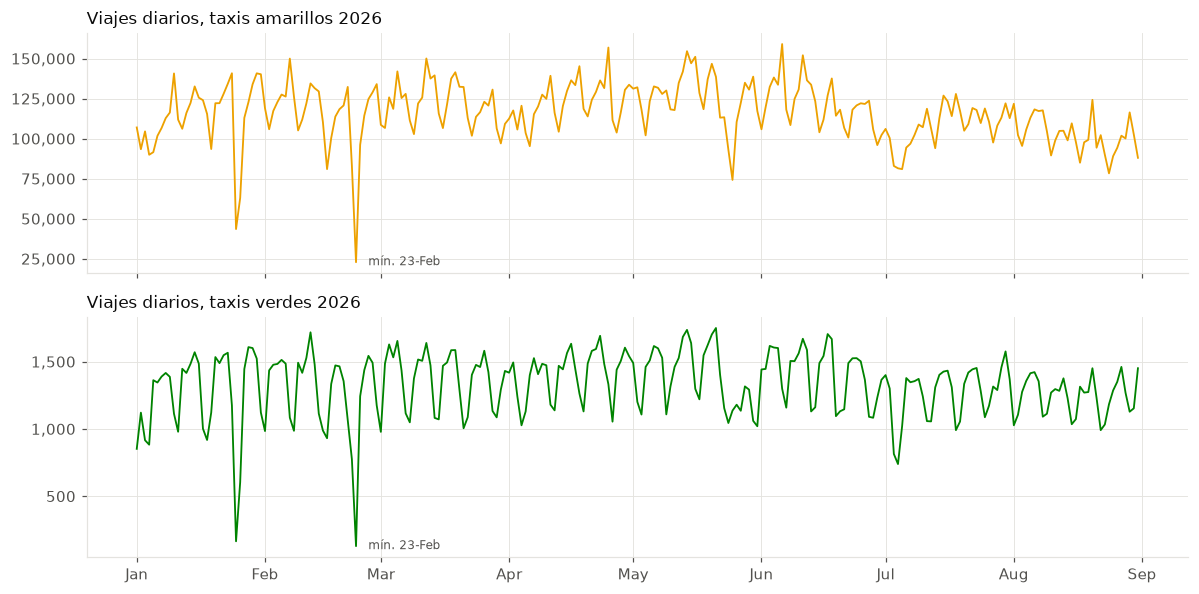

In [24]:
diario = consulta("ejercicio4/p1_viajes_diarios", "Viajes válidos por día y tipo de taxi", """
    SELECT pickup::DATE AS fecha, taxi, count(*) AS viajes
    FROM viajes_limpios
    GROUP BY ALL
    ORDER BY fecha
""", mostrar=False)
mensual = consulta("ejercicio4/p1_viajes_mensuales", "Viajes válidos y promedio diario por mes", """
    SELECT month(pickup) AS mes, taxi, count(*) AS viajes,
           round(count(*) / count(DISTINCT pickup::DATE)) AS viajes_por_dia
    FROM viajes_limpios
    GROUP BY ALL
    ORDER BY taxi, mes
""", mostrar=False)
display(mensual.pivot_table(index="mes", columns="taxi", values=["viajes", "viajes_por_dia"]))

fig, ejes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
for eje, taxi in zip(ejes, ["yellow", "green"]):
    d = diario[diario.taxi == taxi]
    eje.plot(d.fecha, d.viajes, color=COLOR_TAXI[taxi], linewidth=1.2)
    eje.set_title(f"Viajes diarios, taxis {'amarillos' if taxi == 'yellow' else 'verdes'} 2026", loc="left")
    eje.yaxis.set_major_formatter(miles)
    minimo = d.loc[d.viajes.idxmin()]
    eje.annotate(f"mín. {minimo.fecha:%d-%b}", (minimo.fecha, minimo.viajes), textcoords="offset points",
                 xytext=(8, -2), fontsize=8, color=TINTA_2)
ejes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.tight_layout()
guardar(fig, "ej4_p1_viajes_diarios")

In [25]:
extremos = consulta("ejercicio4/p1_dias_extremos", "Días con menos y más viajes amarillos", """
    (SELECT 'menos' AS tipo, pickup::DATE AS fecha, dayname(pickup::DATE) AS dia, count(*) AS viajes
     FROM viajes_limpios WHERE taxi = 'yellow' GROUP BY ALL ORDER BY viajes LIMIT 5)
    UNION ALL
    (SELECT 'mas', pickup::DATE, dayname(pickup::DATE), count(*)
     FROM viajes_limpios WHERE taxi = 'yellow' GROUP BY ALL ORDER BY count(*) DESC LIMIT 5)
""")

[sql/ejercicio4/p1_dias_extremos.sql]  10 filas en 1.46 s
Objetivo: Días con menos y más viajes amarillos
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,tipo,fecha,dia,viajes
0,menos,2026-02-23,Monday,22837
1,menos,2026-01-25,Sunday,43531
2,menos,2026-01-26,Monday,62955
3,menos,2026-05-25,Monday,74194
4,menos,2026-08-24,Monday,78318
5,mas,2026-06-06,Saturday,159022
6,mas,2026-04-25,Saturday,156838
7,mas,2026-05-14,Thursday,154581
8,mas,2026-06-11,Thursday,152044
9,mas,2026-05-16,Saturday,151075


La demanda de taxis amarillos tiene una estacionalidad clara: el promedio diario sube de 113 mil viajes en enero a 126 mil en mayo y baja a 102 mil en agosto. La primavera es la temporada alta y el verano la más baja, cuando parte de la población trabajadora sale de la ciudad. Los verdes se mueven en otra escala, entre 1,244 y 1,408 viajes diarios, con el mismo patrón.

Los días con menos viajes son muy anómalos: el lunes 23 de febrero de 2026 tuvo solo 22,837 viajes amarillos, una caída cercana al 80 % frente a un día normal, y el domingo 25 y lunes 26 de enero también caen fuerte. Por la fecha son compatibles con tormentas invernales, aunque los datos de taxis por sí solos no lo confirman. El lunes 25 de mayo es Memorial Day. Los días con más viajes son sábados y jueves de primavera, con más de 150 mil.

### P2. Hora y día de la semana

[sql/ejercicio4/p2_hora_dia_semana.sql]  168 filas en 1.64 s
Objetivo: Viajes promedio por hora y día de la semana
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


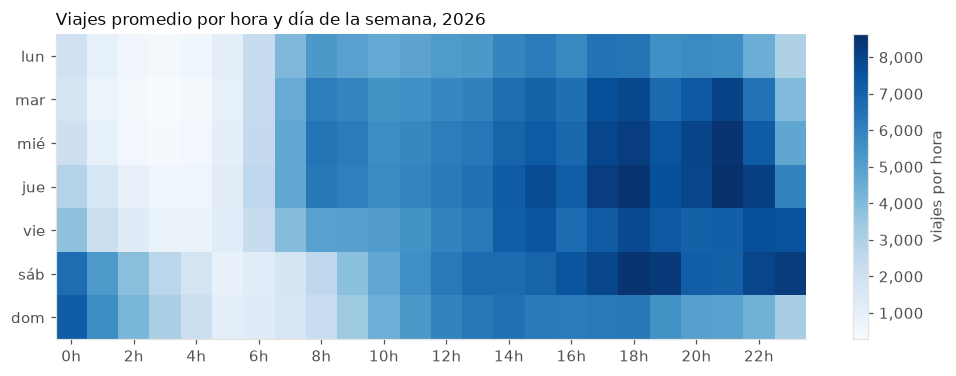

hora,3,5,8,12,15,18,21,23
lun,436,1117,5244,5150,6193,6436,5618,2974
mar,286,982,6100,5839,6977,7822,8034,3978
mié,361,1036,6427,6137,7238,8156,8447,4739
jue,643,1224,6307,6247,7713,8494,8633,5946
vie,837,1261,4930,5987,7431,7802,7120,7524
sáb,2661,897,2511,6259,6944,8489,7089,8241
dom,3078,1079,2203,5943,6247,6295,4897,3186


In [26]:
semana = consulta("ejercicio4/p2_hora_dia_semana", "Viajes promedio por hora y día de la semana", """
    SELECT isodow(pickup) AS dia, hour(pickup) AS hora,
           count(*) / count(DISTINCT pickup::DATE) AS viajes_por_dia
    FROM viajes_limpios
    GROUP BY ALL
""", mostrar=False)
matriz = semana.pivot(index="dia", columns="hora", values="viajes_por_dia")
dias = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]

fig, eje = plt.subplots(figsize=(11, 3.6))
im = eje.imshow(matriz.values, aspect="auto", cmap="Blues")
eje.set_yticks(range(7), dias)
eje.set_xticks(range(0, 24, 2), [f"{h}h" for h in range(0, 24, 2)])
eje.grid(False)
eje.set_title("Viajes promedio por hora y día de la semana, 2026", loc="left")
fig.colorbar(im, ax=eje, format=miles, label="viajes por hora")
guardar(fig, "ej4_p2_mapa_calor")
display(matriz.round(0).astype(int).loc[:, [3, 5, 8, 12, 15, 18, 21, 23]].set_axis(dias))

Entre semana la demanda crece desde las 6h, se mantiene alrededor de 6 mil viajes por hora en el día y alcanza su máximo entre las 18 y 21 horas, con más de 8 mil de martes a jueves. El fin de semana el patrón es otro: la mañana es débil y la madrugada del sábado y domingo tiene entre 2,600 y 3,100 viajes a las 3h, contra 300 a 600 entre semana, lo que refleja la vida nocturna. El punto más bajo de toda la semana es alrededor de las 5h.

### P3. Características de los viajes

In [27]:
distribuciones = consulta("ejercicio4/p3_percentiles", "Percentiles de las variables principales por tipo", """
    UNPIVOT (
        SELECT taxi,
               quantile_cont(trip_distance, [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]) AS distancia_mi,
               quantile_cont(duracion_min, [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]) AS duracion_min,
               quantile_cont(total_amount, [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]) AS total_usd,
               quantile_cont(passenger_count, [0.05, 0.25, 0.5, 0.75, 0.95, 0.99]) AS pasajeros
        FROM viajes_limpios
        GROUP BY taxi
    ) ON distancia_mi, duracion_min, total_usd, pasajeros INTO NAME variable VALUE percentiles
""", mostrar=False)
tabla_p = pd.DataFrame(distribuciones.percentiles.tolist(), columns=["p05", "p25", "p50", "p75", "p95", "p99"])
display(pd.concat([distribuciones[["taxi", "variable"]], tabla_p], axis=1).sort_values(["variable", "taxi"]))

[sql/ejercicio4/p3_percentiles.sql]  8 filas en 9.35 s
Objetivo: Percentiles de las variables principales por tipo
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,taxi,variable,p05,p25,p50,p75,p95,p99
0,green,distancia_mi,0.64,1.33,2.15,3.77,10.63,17.72
4,yellow,distancia_mi,0.50,1.10,1.93,3.95,12.53,19.52
1,green,duracion_min,4.27,8.72,13.35,20.63,44.07,75.03
5,yellow,duracion_min,4.03,8.62,14.10,22.25,44.05,71.30
3,green,pasajeros,1.00,1.00,1.00,1.00,3.00,6.00
7,yellow,pasajeros,1.00,1.00,1.00,1.00,3.00,4.00
2,green,total_usd,9.88,15.12,20.52,29.70,56.40,94.75
6,yellow,total_usd,12.49,17.50,23.58,34.50,77.25,104.96


[sql/ejercicio4/p3_histograma_distancia.sql]  82 filas en 1.55 s
Objetivo: Histograma de distancia en intervalos de media milla
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


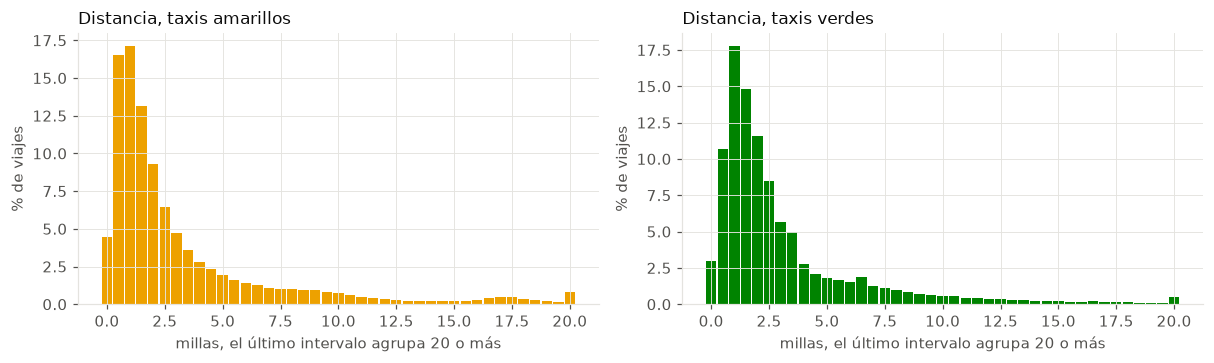

In [28]:
hist = consulta("ejercicio4/p3_histograma_distancia", "Histograma de distancia en intervalos de media milla", """
    SELECT taxi, least(floor(trip_distance * 2) / 2, 20) AS intervalo, count(*) AS viajes
    FROM viajes_limpios
    GROUP BY ALL
    ORDER BY taxi, intervalo
""", mostrar=False)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    d = hist[hist.taxi == taxi]
    eje.bar(d.intervalo, d.viajes / d.viajes.sum() * 100, width=0.45, color=COLOR_TAXI[taxi])
    eje.set_title(f"Distancia, taxis {'amarillos' if taxi == 'yellow' else 'verdes'}", loc="left")
    eje.set_xlabel("millas, el último intervalo agrupa 20 o más")
    eje.set_ylabel("% de viajes")
fig.tight_layout()
guardar(fig, "ej4_p3_histograma_distancia")

Las distribuciones son muy asimétricas. La mediana de distancia es de 1.93 millas en amarillos y 2.15 en verdes, pero la media supera las 3.3 millas porque una cola de viajes largos, sobre todo a aeropuertos, la arrastra: el percentil 95 es de 12.5 millas en amarillos y 10.6 en verdes. La duración mediana es de unos 14 minutos y el monto mediano de 23.58 dólares en amarillos y 20.52 en verdes. Al menos el 75 % de los viajes lleva un solo pasajero. Por eso en el análisis se reportan medianas y percentiles junto a los promedios.

### P4. Diferencias entre taxis amarillos y verdes

In [29]:
comparacion = consulta("ejercicio4/p4_comparacion_tipos", "Perfil comparativo de taxis amarillos y verdes", """
    SELECT v.taxi,
           count(*) AS viajes,
           round(avg(trip_distance), 2) AS distancia_prom,
           round(median(duracion_min), 1) AS duracion_mediana,
           round(avg(total_amount), 2) AS ticket_prom,
           round(avg(passenger_count), 2) AS pasajeros_prom,
           round(100.0 * count_if(payment_type = 1) / count(*), 1) AS pct_tarjeta,
           round(100.0 * count_if(payment_type = 2) / count(*), 1) AS pct_efectivo,
           round(100.0 * count_if(z.borough = 'Manhattan') / count(*), 1) AS pct_origen_manhattan,
           round(100.0 * count_if(pu_location_id IN (1, 132, 138)) / count(*), 1) AS pct_origen_aeropuerto,
           round(100.0 * count_if(coalesce(cbd_congestion_fee, 0) > 0) / count(*), 1) AS pct_cargo_cbd
    FROM viajes_limpios v
    LEFT JOIN read_csv('data/raw/zones/taxi_zone_lookup.csv') z ON v.pu_location_id = z.LocationID
    GROUP BY v.taxi
""")

[sql/ejercicio4/p4_comparacion_tipos.sql]  2 filas en 2.81 s
Objetivo: Perfil comparativo de taxis amarillos y verdes
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,taxi,viajes,distancia_prom,duracion_mediana,ticket_prom,pasajeros_prom,pct_tarjeta,pct_efectivo,pct_origen_manhattan,pct_origen_aeropuerto,pct_cargo_cbd
0,green,321569,3.35,13.40,25.41,1.30,65.60,19.40,59.60,0.00,8.50
1,yellow,28226284,3.51,14.10,30.24,1.25,65.40,9.10,86.60,6.50,72.40


[sql/ejercicio4/p4_borough_origen.sql]  15 filas en 1.63 s
Objetivo: Distribución del borough de origen por tipo
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


taxi,green,yellow
borough,,
Manhattan,59.60,86.60
Queens,22.00,8.80
Brooklyn,15.70,3.60
Bronx,2.50,0.80
Unknown,0.10,0.10
Staten Island,0.00,0.00
EWR,0.00,0.00
N/A,0.10,0.00


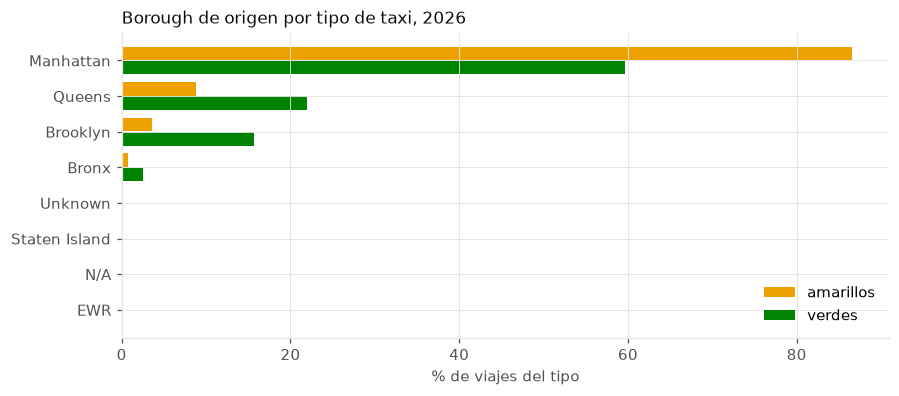

In [30]:
borough = consulta("ejercicio4/p4_borough_origen", "Distribución del borough de origen por tipo", """
    SELECT v.taxi, z.Borough AS borough, count(*) AS viajes,
           round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY v.taxi), 1) AS pct
    FROM viajes_limpios v
    JOIN read_csv('data/raw/zones/taxi_zone_lookup.csv') z ON v.pu_location_id = z.LocationID
    GROUP BY v.taxi, z.Borough
    ORDER BY v.taxi, viajes DESC
""", mostrar=False)
tabla_b = borough.pivot_table(index="borough", columns="taxi", values="pct", fill_value=0).sort_values("yellow")
display(tabla_b.sort_values("yellow", ascending=False))

fig, eje = plt.subplots(figsize=(9, 3.6))
y = range(len(tabla_b))
eje.barh([i + 0.2 for i in y], tabla_b["yellow"], height=0.38, color=COLOR_TAXI["yellow"], label="amarillos")
eje.barh([i - 0.2 for i in y], tabla_b["green"], height=0.38, color=COLOR_TAXI["green"], label="verdes")
eje.set_yticks(list(y), tabla_b.index)
eje.set_xlabel("% de viajes del tipo")
eje.set_title("Borough de origen por tipo de taxi, 2026", loc="left")
eje.legend(loc="lower right")
guardar(fig, "ej4_p4_borough")

Los taxis verdes son solo el 1.1 % de los viajes válidos de 2026 y atienden otro mercado. Solo el 59.6 % de sus viajes empieza en Manhattan, contra el 86.6 % de los amarillos; Queens y Brooklyn concentran el 37.7 % de sus orígenes contra el 12.4 % en amarillos. Ningún viaje verde empieza en un aeropuerto, mientras que el 6.5 % de los amarillos sale de JFK, LaGuardia o Newark. Esto coincide con la regla de la TLC que limita a los verdes a recoger pasajeros en el norte de Manhattan y en los otros boroughs, fuera de los aeropuertos.

Los verdes usan el doble de efectivo, 19.4 % contra 9.1 %, tienen un ticket promedio 4.83 dólares menor y solo el 8.5 % paga el cargo CBD, contra el 72.4 % de los amarillos. La distancia promedio, en cambio, es casi igual: 3.35 contra 3.51 millas.

### P5. Variables de pago

In [31]:
pagos = consulta("ejercicio4/p5_metodo_pago", "Método de pago y propina según tipo de taxi", """
    SELECT taxi,
           CASE payment_type WHEN 0 THEN '0 flex fare' WHEN 1 THEN '1 tarjeta' WHEN 2 THEN '2 efectivo'
                WHEN 3 THEN '3 sin cargo' WHEN 4 THEN '4 disputa' ELSE 'otro o nulo' END AS metodo,
           count(*) AS viajes,
           round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY taxi), 2) AS pct_viajes,
           round(avg(tip_amount), 2) AS propina_prom,
           round(100.0 * sum(tip_amount) / nullif(sum(fare_amount), 0), 2) AS pct_propina_sobre_tarifa,
           round(100.0 * count_if(tip_amount > 0) / count(*), 1) AS pct_con_propina
    FROM viajes_limpios
    GROUP BY taxi, metodo
    ORDER BY taxi, metodo
""")

[sql/ejercicio4/p5_metodo_pago.sql]  10 filas en 1.59 s
Objetivo: Método de pago y propina según tipo de taxi
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,taxi,metodo,viajes,pct_viajes,propina_prom,pct_propina_sobre_tarifa,pct_con_propina
0,green,1 tarjeta,210959,65.60,3.80,21.01,91.50
1,green,2 efectivo,62472,19.43,0.00,0.00,0.00
2,green,3 sin cargo,638,0.20,0.01,0.04,0.30
3,green,4 disputa,249,0.08,0.00,0.00,0.00
4,green,otro o nulo,47251,14.69,0.76,8.05,15.60
5,yellow,0 flex fare,7041227,24.95,0.40,1.56,8.30
6,yellow,1 tarjeta,18452992,65.38,4.26,21.60,91.10
7,yellow,2 efectivo,2558311,9.06,0.00,0.00,0.00
8,yellow,3 sin cargo,55846,0.20,0.00,0.00,0.00
9,yellow,4 disputa,117908,0.42,0.00,0.01,0.00


In [32]:
propinas = consulta("ejercicio4/p5_distribucion_propina", "Distribución del porcentaje de propina con tarjeta", """
    SELECT CASE WHEN tip_amount = 0 THEN '0'
                WHEN pct < 15 THEN '0 a 15'
                WHEN pct < 19 THEN '15 a 19'
                WHEN pct < 24 THEN '19 a 24'
                WHEN pct < 29 THEN '24 a 29'
                WHEN pct < 35 THEN '29 a 35'
                ELSE '35 o más' END AS rango_pct,
           count(*) AS viajes,
           round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct_viajes
    FROM (SELECT tip_amount, 100 * tip_amount / (total_amount - tip_amount) AS pct
          FROM viajes_limpios
          WHERE payment_type = 1 AND taxi = 'yellow' AND total_amount - tip_amount > 0)
    GROUP BY rango_pct
    ORDER BY min(pct)
""")

[sql/ejercicio4/p5_distribucion_propina.sql]  7 filas en 1.62 s
Objetivo: Distribución del porcentaje de propina con tarjeta
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,rango_pct,viajes,pct_viajes
0,0,1636088,8.90
1,0 a 15,3613320,19.60
2,15 a 19,916284,5.00
3,19 a 24,9898408,53.60
4,24 a 29,1639408,8.90
5,29 a 35,638460,3.50
6,35 o más,111024,0.60


El 65 % de los viajes de ambos tipos se paga con tarjeta. En amarillos, uno de cada cuatro viajes es Flex Fare, una categoría que no existe en verdes. El efectivo es el 9.1 % en amarillos y el 19.4 % en verdes.

La propina solo puede analizarse en pagos con tarjeta: el diccionario aclara que tip_amount no incluye propinas en efectivo, por eso todos los viajes en efectivo tienen propina cero. Con tarjeta, el 91 % de los pasajeros deja propina y esta equivale al 21.6 % de la tarifa en amarillos y al 21.0 % en verdes. La distribución está muy concentrada: el 53.6 % de las propinas con tarjeta está entre 19 % y 24 % del monto, lo que coincide con la opción de 20 % que suelen sugerir las pantallas de pago del taxi. Los viajes Flex Fare casi no registran propina, 1.56 % de la tarifa, probablemente porque esa propina no pasa por el taxímetro.

### P6. Composición del monto total

In [33]:
componentes = consulta("ejercicio4/p6_componentes_total", "Aporte promedio de cada componente al total", """
    UNPIVOT (
        SELECT taxi,
               avg(fare_amount) AS tarifa, avg(extra) AS extra, avg(mta_tax) AS mta_tax,
               avg(tip_amount) AS propina, avg(tolls_amount) AS peajes,
               avg(improvement_surcharge) AS improvement, avg(congestion_surcharge) AS congestion_nys,
               avg(coalesce(airport_fee, 0)) AS aeropuerto, avg(coalesce(cbd_congestion_fee, 0)) AS cbd,
               avg(total_amount) AS total
        FROM viajes_limpios
        GROUP BY taxi
    ) ON COLUMNS(* EXCLUDE (taxi)) INTO NAME componente VALUE usd
""", mostrar=False)
tabla_c = componentes.pivot(index="componente", columns="taxi", values="usd")
tabla_c["pct_yellow"] = tabla_c["yellow"] / tabla_c.loc["total", "yellow"] * 100
tabla_c["pct_green"] = tabla_c["green"] / tabla_c.loc["total", "green"] * 100
display(tabla_c.sort_values("yellow", ascending=False))
suma = tabla_c.drop("total").sum()
print(f"Suma de componentes contra total: yellow {suma.yellow:.2f} vs {tabla_c.loc['total','yellow']:.2f}"
      f" | green {suma.green:.2f} vs {tabla_c.loc['total','green']:.2f}")

[sql/ejercicio4/p6_componentes_total.sql]  20 filas en 2.10 s
Objetivo: Aporte promedio de cada componente al total
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


taxi,green,yellow,pct_yellow,pct_green
componente,,,,
total,25.41,30.24,100.00,100.00
tarifa,16.76,21.29,70.40,65.95
propina,2.60,2.88,9.53,10.24
congestion_nys,0.92,2.26,7.46,3.60
extra,0.84,1.17,3.86,3.29
improvement,0.92,0.98,3.23,3.62
peajes,0.30,0.55,1.82,1.19
cbd,0.06,0.54,1.80,0.25
mta_tax,0.56,0.50,1.64,2.19


Suma de componentes contra total: yellow 30.29 vs 30.24 | green 22.96 vs 25.41


En amarillos la tarifa del taxímetro es el 70.4 % del total, la propina el 9.5 % y el recargo estatal por congestión el 7.5 %. El cargo CBD aporta en promedio 0.54 dólares, el 1.8 % del total, porque el 72 % de los viajes paga 0.75. En amarillos la suma de componentes coincide con el total. En verdes no: los componentes suman 22.96 contra un total de 25.41, porque los registros verdes sin payment_type traen una tarifa de 9.48 dólares y un total de 30.89, es decir, su total no está desglosado. Es el mismo patrón de Flex Fare que en amarillos, aunque en verdes no está codificado.

### P7. Valores atípicos e inconsistencias

In [34]:
proveedor = consulta("ejercicio4/p7_calidad_proveedor", "Tasa de registros inválidos por proveedor", """
    SELECT taxi, vendor_id,
           CASE vendor_id WHEN 1 THEN 'Creative Mobile' WHEN 2 THEN 'Curb Mobility'
                WHEN 6 THEN 'Myle' WHEN 7 THEN 'Helix' ELSE 'otro' END AS proveedor,
           count(*) AS registros,
           round(100.0 * count_if(calidad <> 'valido') / count(*), 2) AS pct_invalidos,
           mode(calidad) FILTER (WHERE calidad <> 'valido') AS falla_principal
    FROM viajes_calidad
    GROUP BY ALL
    ORDER BY taxi, vendor_id
""")

[sql/ejercicio4/p7_calidad_proveedor.sql]  7 filas en 1.60 s
Objetivo: Tasa de registros inválidos por proveedor
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,taxi,vendor_id,proveedor,registros,pct_invalidos,falla_principal
0,green,1,Creative Mobile,28696,7.33,distancia_no_positiva
1,green,2,Curb Mobility,273571,4.76,distancia_no_positiva
2,green,6,Myle,34847,1.22,monto_no_positivo
3,yellow,1,Creative Mobile,5467071,1.82,distancia_no_positiva
4,yellow,2,Curb Mobility,23809774,4.24,distancia_no_positiva
5,yellow,6,Myle,59390,1.27,monto_no_positivo
6,yellow,7,Helix,367120,100.00,duracion_no_positiva


In [35]:
atipicos = consulta("ejercicio4/p7_atipicos_iqr", "Atípicos de monto y distancia según regla IQR entre válidos", """
    WITH limites AS (
        SELECT taxi,
               quantile_cont(total_amount, 0.25) AS q1_t, quantile_cont(total_amount, 0.75) AS q3_t,
               quantile_cont(trip_distance, 0.25) AS q1_d, quantile_cont(trip_distance, 0.75) AS q3_d
        FROM viajes_limpios GROUP BY taxi
    )
    SELECT v.taxi,
           round(any_value(q3_t + 1.5 * (q3_t - q1_t)), 2) AS limite_total,
           round(100.0 * count_if(total_amount > q3_t + 1.5 * (q3_t - q1_t)) / count(*), 2) AS pct_total_atipico,
           round(any_value(q3_d + 1.5 * (q3_d - q1_d)), 2) AS limite_distancia,
           round(100.0 * count_if(trip_distance > q3_d + 1.5 * (q3_d - q1_d)) / count(*), 2) AS pct_dist_atipica,
           round(100.0 * count_if(trip_distance > q3_d + 1.5 * (q3_d - q1_d) AND pu_location_id IN (1, 132, 138)
                 OR trip_distance > q3_d + 1.5 * (q3_d - q1_d) AND do_location_id IN (1, 132, 138))
                 / nullif(count_if(trip_distance > q3_d + 1.5 * (q3_d - q1_d)), 0), 1) AS pct_atipicos_aeropuerto
    FROM viajes_limpios v JOIN limites USING (taxi)
    GROUP BY v.taxi
""")

[sql/ejercicio4/p7_atipicos_iqr.sql]  2 filas en 7.75 s
Objetivo: Atípicos de monto y distancia según regla IQR entre válidos
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,taxi,limite_total,pct_total_atipico,limite_distancia,pct_dist_atipica,pct_atipicos_aeropuerto
0,yellow,60.00,8.51,8.23,10.91,61.10
1,green,51.57,6.56,7.43,10.17,9.60


In [36]:
ejemplos = consulta("ejercicio4/p7_ejemplos_extremos", "Ejemplos de registros descartados más extremos", """
    SELECT calidad, taxi, pickup, dropoff, round(duracion_min, 1) AS duracion_min, trip_distance,
           fare_amount, total_amount, pu_location_id, do_location_id
    FROM viajes_calidad
    WHERE calidad <> 'valido'
    QUALIFY row_number() OVER (PARTITION BY calidad ORDER BY abs(trip_distance) + abs(total_amount) DESC) = 1
    ORDER BY calidad
""")

[sql/ejercicio4/p7_ejemplos_extremos.sql]  8 filas en 1.62 s
Objetivo: Ejemplos de registros descartados más extremos
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


,calidad,taxi,pickup,dropoff,duracion_min,trip_distance,fare_amount,total_amount,pu_location_id,do_location_id
0,distancia_mayor_100mi,yellow,2026-02-20 11:40:00,2026-02-20 12:02:00,22.00,"328,522.20",31.11,35.86,125,50
1,distancia_no_positiva,yellow,2026-05-22 15:00:13,2026-05-22 15:00:23,0.20,0.00,999.00,"1,000.00",197,197
2,duracion_mayor_6h,yellow,2026-04-24 01:35:00,2026-04-24 08:10:00,395.00,"206,279.09",27.85,31.90,232,113
3,duracion_no_positiva,yellow,2026-06-07 07:16:20,2026-06-07 07:16:20,0.00,0.01,"7,045.00","7,053.50",138,138
4,fecha_fuera_de_archivo,yellow,2025-12-31 23:58:58,2026-01-01 01:04:39,65.70,40.14,167.20,198.70,132,1
5,monto_mayor_1000,yellow,2026-05-30 11:19:25,2026-05-30 11:56:21,36.90,5.29,"1,061.72","1,065.72",225,45
6,monto_no_positivo,yellow,2026-06-19 13:47:11,2026-06-19 14:30:08,43.00,11.19,-985.00,-989.25,161,134
7,velocidad_mayor_80mph,yellow,2026-01-12 15:52:19,2026-01-12 15:52:27,0.10,66.05,801.70,804.20,193,193


La calidad depende mucho del proveedor. Helix, VendorID 7, tiene el 100 % de sus 367,120 registros de 2026 marcados como inválidos: en todos sus viajes la hora de llegada es exactamente igual a la de salida, aunque la distancia y el monto son normales. Es un error sistemático del proveedor y no de los viajes. Se decidió excluirlos porque sin duración no se pueden calcular velocidades ni duraciones, pero eso quita el 1.2 % de los viajes amarillos, algo que hay que considerar al comparar volúmenes. Curb Mobility, que reporta el 80 % de los viajes, tiene 4.24 % de inválidos, sobre todo por distancia cero; Creative Mobile tiene 1.82 %.

Entre los viajes válidos, la regla IQR marca como atípicos al 8.5 % de los montos amarillos sobre 60 dólares y al 10.9 % de las distancias sobre 8.2 millas. El 61 % de esas distancias atípicas son viajes desde o hacia aeropuertos, así que son legítimas y no se eliminan. Los ejemplos descartados sí son errores evidentes: 328 mil millas en 22 minutos, una tarifa de 7,045 dólares con duración cero o una tarifa de -985 dólares.

### P8. Velocidad promedio por hora

[sql/ejercicio4/p8_velocidad_hora.sql]  48 filas en 1.48 s
Objetivo: Velocidad promedio por hora y tipo de taxi
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2026}/*.parquet


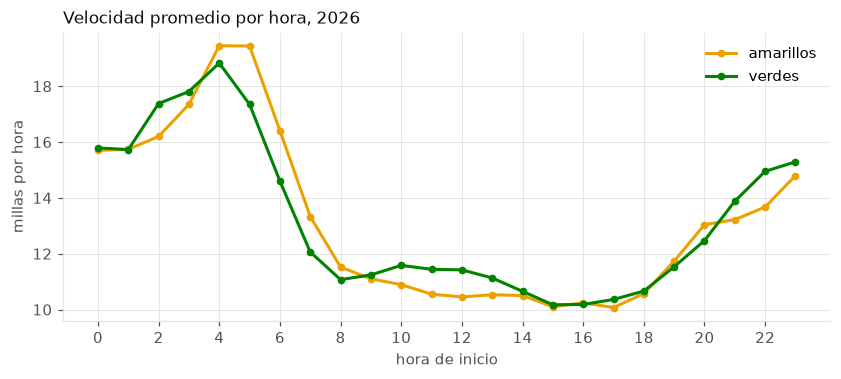

hora,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
taxi,,,,,,,,,,,,,,,,,,,,,,,,
green,15.79,15.73,17.38,17.81,18.83,17.35,14.60,12.06,11.07,11.24,11.58,11.44,11.42,11.13,10.65,10.17,10.18,10.36,10.66,11.53,12.47,13.88,14.95,15.29
yellow,15.70,15.74,16.20,17.35,19.45,19.44,16.41,13.33,11.52,11.10,10.89,10.55,10.45,10.53,10.50,10.10,10.24,10.07,10.57,11.73,13.04,13.22,13.67,14.80


In [37]:
velocidad = consulta("ejercicio4/p8_velocidad_hora", "Velocidad promedio por hora y tipo de taxi", """
    SELECT taxi, hour(pickup) AS hora,
           round(sum(trip_distance) / sum(duracion_min / 60), 2) AS mph
    FROM viajes_limpios
    GROUP BY ALL
    ORDER BY taxi, hora
""", mostrar=False)
fig, eje = plt.subplots(figsize=(9, 3.4))
for taxi in ["yellow", "green"]:
    d = velocidad[velocidad.taxi == taxi]
    eje.plot(d.hora, d.mph, color=COLOR_TAXI[taxi], marker="o", markersize=4,
             label="amarillos" if taxi == "yellow" else "verdes")
eje.set_xticks(range(0, 24, 2))
eje.set_xlabel("hora de inicio")
eje.set_ylabel("millas por hora")
eje.set_title("Velocidad promedio por hora, 2026", loc="left")
eje.legend()
guardar(fig, "ej4_p8_velocidad")
display(velocidad.pivot(index="hora", columns="taxi", values="mph").T)

La velocidad promedio cae a la mitad durante el día: pasa de unas 19.5 mph a las 4 y 5h a alrededor de 10 mph entre las 10 y las 18 horas, con el mínimo cerca de las 17h. Los verdes son ligeramente más rápidos al mediodía porque circulan más fuera del centro. Esta curva explica por qué los viajes cortos en hora pico cuestan más: la tarifa combina distancia y tiempo detenido.

### 4.5 Hallazgos relevantes

1. Uno de cada cuatro viajes amarillos de 2026 es Flex Fare, y esos registros no traen pasajeros, código de tarifa ni recargos desglosados. Sin entender eso se concluiría que una cuarta parte de los datos está incompleta o se imputarían valores sin sentido.
2. La calidad depende del proveedor: Helix registra todos sus viajes con duración cero. Cualquier métrica de duración o velocidad que no filtre esos registros queda sesgada, y al filtrarlos se pierde el 1.2 % del volumen amarillo.
3. Amarillos y verdes son mercados distintos: los verdes son el 1.1 % del volumen, trabajan fuera del centro de Manhattan y sin aeropuertos, usan el doble de efectivo y casi no pagan el cargo CBD.
4. La demanda tiene picos vespertinos entre semana y madrugadas activas el fin de semana, mientras que la velocidad cae a la mitad entre las 5h y las 17h.
5. La propina con tarjeta es muy estable, cerca del 21 % de la tarifa, y está anclada a la opción sugerida de la pantalla.

## Ejercicio 5. Incorporación de datos de 2024

### 5.1 a 5.4 Descarga

El script ya recibe los años como parámetro, así que incorporar 2024 no requiere modificar código: basta con ejecutarlo con --anio 2024 2026. La ejecución original quedó en docs/logs/descarga_2024_2026.txt; aquí se vuelve a ejecutar.

In [38]:
log = Path("docs/logs/descarga_2024_2026.txt").read_text().splitlines()
print("Registro original:", sum("listo (" in l for l in log), "descargados y",
      sum("ya existe" in l for l in log), "omitidos de 2026")
manifiesto = descargar(2024, 2026)

Registro original: 24 descargados y 17 omitidos de 2026


Archivos omitidos por existir: 41 | descargados ahora: 0
RESUMEN
  anios         : 2024, 2026
  descargados   : 0
  ya existian   : 40
  no publicados : 4
      yellow 2026-09, yellow 2026-10, green 2026-09, green 2026-10
  fallidos      : 0
  archivos locales validados : 40
  registros totales          : 71,870,407
  archivos con problemas     : 0
  manifiesto                 : docs/manifest_descargas.csv


### 5.5 Verificación de los archivos incorporados

In [39]:
display(manifiesto.groupby(["tipo", "anio"])
        .agg(archivos=("mes", "count"), meses=("mes", lambda m: f"{m.min()}-{m.max()}"),
             registros=("registros", "sum"), tamanio_ok=("tamanio_ok", "all"),
             legibles=("parquet_legible", "all"), columnas=("columnas", lambda c: sorted(set(c))))
        .reset_index())

,tipo,anio,archivos,meses,registros,tamanio_ok,legibles,columnas
0,green,2024,12,1-12,660218,True,True,[20]
1,green,2026,8,1-8,337114,True,True,"[21, 22]"
2,yellow,2024,12,1-12,41169720,True,True,[19]
3,yellow,2026,8,1-8,29703355,True,True,"[20, 21]"


### 5.6 Consulta conjunta de 2024 y 2026

In [40]:
usar_anios([2024, 2026])
anual = consulta("ejercicio5/01_registros_por_anio", "Registros, fechas y archivos por año y tipo en la vista", """
    SELECT anio_archivo AS anio, taxi,
           count(DISTINCT mes_archivo) AS meses,
           count(*) AS registros,
           min(pickup) FILTER (WHERE calidad = 'valido') AS primer_viaje,
           max(pickup) FILTER (WHERE calidad = 'valido') AS ultimo_viaje,
           round(100.0 * count_if(calidad <> 'valido') / count(*), 2) AS pct_invalidos
    FROM viajes_calidad
    GROUP BY ALL
    ORDER BY anio, taxi
""")
totales = anual.groupby("anio").registros.sum()
print("Coincide con el manifiesto:",
      (totales.values == manifiesto.groupby("anio").registros.sum().values).all())

Vistas creadas para [2024, 2026]


[sql/ejercicio5/01_registros_por_anio.sql]  4 filas en 3.21 s
Objetivo: Registros, fechas y archivos por año y tipo en la vista
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2026}/*.parquet


,anio,taxi,meses,registros,primer_viaje,ultimo_viaje,pct_invalidos
0,2024,green,12,660218,2024-01-01 00:03:57,2024-12-31 23:56:49,6.21
1,2024,yellow,12,41169720,2024-01-01 00:00:00,2024-12-31 23:59:58,3.63
2,2026,green,8,337114,2026-01-01 00:03:27,2026-08-31 23:58:28,4.61
3,2026,yellow,8,29703355,2026-01-01 00:00:00,2026-08-31 23:59:59,4.97


Coincide con el manifiesto: True


In [41]:
columnas_anio = consulta("ejercicio5/02_esquema_por_anio", "Columnas presentes por año para detectar cambios de esquema", """
    SELECT name AS columna,
           count(DISTINCT file_name) FILTER (WHERE file_name LIKE '%/2024/%') AS archivos_2024,
           count(DISTINCT file_name) FILTER (WHERE file_name LIKE '%/2026/%') AS archivos_2026,
           string_agg(DISTINCT type, ', ') AS tipos
    FROM parquet_schema(['data/raw/*/2024/*.parquet', 'data/raw/*/2026/*.parquet'])
    WHERE name <> 'schema'
    GROUP BY name
    HAVING archivos_2024 <> 24 OR archivos_2026 <> 16 OR count(DISTINCT type) > 1
    ORDER BY columna
""")

[sql/ejercicio5/02_esquema_por_anio.sql]  9 filas en 0.10 s
Objetivo: Columnas presentes por año para detectar cambios de esquema
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2026}/*.parquet


,columna,archivos_2024,archivos_2026,tipos
0,Airport_fee,12,8,DOUBLE
1,cbd_congestion_fee,0,16,DOUBLE
2,ehail_fee,12,8,DOUBLE
3,lpep_dropoff_datetime,12,8,INT64
4,lpep_pickup_datetime,12,8,INT64
5,request_source,0,6,BYTE_ARRAY
6,tpep_dropoff_datetime,12,8,INT64
7,tpep_pickup_datetime,12,8,INT64
8,trip_type,12,8,INT64


In [42]:
nulos_anio = consulta("ejercicio5/03_columnas_nuevas", "Cómo se ven las columnas nuevas al unir años", """
    SELECT anio_archivo AS anio, taxi,
           count(*) AS registros,
           count(cbd_congestion_fee) AS con_cbd,
           count(request_source) AS con_request_source,
           count(airport_fee) AS con_airport_fee,
           count(trip_type) AS con_trip_type
    FROM viajes
    GROUP BY ALL
    ORDER BY anio, taxi
""")

[sql/ejercicio5/03_columnas_nuevas.sql]  4 filas en 0.41 s
Objetivo: Cómo se ven las columnas nuevas al unir años
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2026}/*.parquet


,anio,taxi,registros,con_cbd,con_request_source,con_airport_fee,con_trip_type
0,2024,green,660218,0,0,0,635808
1,2024,yellow,41169720,0,0,37078488,0
2,2026,green,337114,337114,19211,0,288337
3,2026,yellow,29703355,29703355,2903446,21986667,0


In [43]:
continuidad = consulta("ejercicio5/04_continuidad_mensual", "Verificar que cada mes tenga datos en ambos años", """
    SELECT mes_archivo AS mes,
           sum(CASE WHEN anio_archivo = 2024 AND taxi = 'yellow' THEN 1 END) AS yellow_2024,
           sum(CASE WHEN anio_archivo = 2026 AND taxi = 'yellow' THEN 1 END) AS yellow_2026,
           sum(CASE WHEN anio_archivo = 2024 AND taxi = 'green' THEN 1 END) AS green_2024,
           sum(CASE WHEN anio_archivo = 2026 AND taxi = 'green' THEN 1 END) AS green_2026
    FROM viajes
    GROUP BY mes
    ORDER BY mes
""")

[sql/ejercicio5/04_continuidad_mensual.sql]  12 filas en 0.32 s
Objetivo: Verificar que cada mes tenga datos en ambos años
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2026}/*.parquet


,mes,yellow_2024,yellow_2026,green_2024,green_2026
0,1,"2,964,624.00","3,724,889.00","56,551.00","40,272.00"
1,2,"3,007,526.00","3,399,866.00","53,577.00","37,373.00"
2,3,"3,582,628.00","3,952,451.00","57,457.00","44,208.00"
3,4,"3,514,289.00","3,831,240.00","56,471.00","44,238.00"
4,5,"3,723,833.00","4,090,836.00","61,003.00","44,921.00"
5,6,"3,539,193.00","3,837,248.00","54,748.00","44,163.00"
6,7,"3,076,903.00","3,530,109.00","51,837.00","41,252.00"
7,8,"2,979,183.00","3,336,716.00","51,771.00","40,687.00"
8,9,"3,633,030.00",NaN,"54,440.00",NaN
9,10,"3,833,771.00",NaN,"56,147.00",NaN


### 5.7 Hace falta modificar las consultas anteriores

Se vuelven a ejecutar, sin cambiar una sola línea, todas las consultas guardadas en sql/ejercicio4. La vista viajes ahora apunta a 2024 y 2026.

In [44]:
def reejecutar(carpeta, conexion=None):
    conexion = conexion or con
    filas = []
    for ruta in sorted(Path(carpeta).glob("*.sql")):
        inicio = time.perf_counter()
        try:
            n, estado = len(conexion.sql(ruta.read_text()).df()), "ok"
        except Exception as error:
            n, estado = 0, f"error: {str(error)[:80]}"
        filas.append({"consulta": ruta.name, "estado": estado, "filas": n,
                      "segundos": round(time.perf_counter() - inicio, 2)})
    return pd.DataFrame(filas)

display(reejecutar("sql/ejercicio4"))

,consulta,estado,filas,segundos
0,00_clasificacion_calidad.sql,ok,17,3.09
1,p1_dias_extremos.sql,ok,10,3.27
2,p1_viajes_diarios.sql,ok,1218,3.15
3,p1_viajes_mensuales.sql,ok,24,3.15
4,p2_hora_dia_semana.sql,ok,168,3.19
5,p3_histograma_distancia.sql,ok,82,3.30
6,p3_percentiles.sql,ok,8,21.38
7,p4_borough_origen.sql,ok,15,3.53
8,p4_comparacion_tipos.sql,ok,2,7.03
9,p5_distribucion_propina.sql,ok,7,3.58


In [45]:
comparacion_anios = consulta("ejercicio5/05_comparacion_anual", "Perfil comparativo por año con la misma lógica del ejercicio 4", """
    SELECT anio_archivo AS anio, taxi,
           count(*) AS viajes,
           round(count(*) / count(DISTINCT pickup::DATE)) AS viajes_por_dia,
           round(avg(trip_distance), 2) AS distancia_prom,
           round(avg(total_amount), 2) AS ticket_prom,
           round(100.0 * count_if(payment_type = 2) / count(*), 1) AS pct_efectivo,
           round(avg(coalesce(cbd_congestion_fee, 0)), 2) AS cbd_prom
    FROM viajes_limpios
    WHERE mes_archivo <= 8
    GROUP BY ALL
    ORDER BY taxi, anio
""")

[sql/ejercicio5/05_comparacion_anual.sql]  4 filas en 3.33 s
Objetivo: Perfil comparativo por año con la misma lógica del ejercicio 4
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2026}/*.parquet


,anio,taxi,viajes,viajes_por_dia,distancia_prom,ticket_prom,pct_efectivo,cbd_prom
0,2024,green,415758,"1,704.00",2.92,23.76,27.80,0.00
1,2026,green,321569,"1,323.00",3.35,25.41,19.40,0.06
2,2024,yellow,25491662,"104,474.00",3.42,28.32,13.80,0.00
3,2026,yellow,28226284,"116,158.00",3.51,30.24,9.10,0.54


Resultados de la validación:

- La vista conjunta contiene 41,169,720 viajes amarillos y 660,218 verdes de 2024, y los totales por año coinciden con el manifiesto.
- Ningún archivo de 2024 tiene cbd_congestion_fee ni request_source, y los tipos físicos de las columnas comunes son idénticos entre años.
- Gracias a esquema_base esas columnas aparecen como NULL en 2024 en lugar de romper la consulta.
- Todos los meses tienen datos para ambos tipos: 12 en 2024 y 8 en 2026.
- El porcentaje de registros inválidos sube de 3.63 % a 4.97 % en amarillos, lo que coincide con la aparición de Helix.

Al comparar enero a agosto, los viajes amarillos por día suben de 104,474 en 2024 a 116,158 en 2026, mientras que los verdes bajan de 1,704 a 1,323. El efectivo cae de 13.8 % a 9.1 % en amarillos y de 27.8 % a 19.4 % en verdes, y el ticket promedio amarillo sube de 28.32 a 30.24 dólares.

Ninguna consulta necesitó cambios: todas se ejecutaron sin error sobre el conjunto ampliado. Las del ejercicio 3 sí apuntan explícitamente a data/raw/*/2026 porque su objetivo era explorar ese año; para incluir otro año bastaría con cambiar el patrón de ruta. Hay dos matices que no son errores pero cambian la interpretación:

- cbd_congestion_fee es NULL en todo 2024 porque el cargo empezó el 5 de enero de 2025. Las consultas que lo promedian deben leer NULL como no existía, por eso los indicadores usan coalesce o count_if(cbd_congestion_fee > 0).
- Los promedios anuales comparan años con distinta cantidad de meses: 2024 tiene 12 y 2026 tiene 8. Para comparar años se filtra a enero a agosto, como en la consulta anterior.

### 5.8 Consultas de validación

Las consultas de validación quedaron en sql/ejercicio5: registros por año contra el manifiesto, esquema por año, columnas nuevas, continuidad mensual y comparación anual.

### 5.9 Diseño que permite incorporar archivos sin cambiar el flujo

- Convención de rutas: data/raw/tipo/año/archivo. El año es un parámetro y la ruta se arma igual para cualquier año.
- Lectura por patrones glob: las vistas leen data/raw/yellow/*/*.parquet, así que un archivo nuevo entra solo en la siguiente consulta, sin registrar nada.
- union_by_name y esquema_base: las columnas que aparecen o faltan según el año se rellenan con NULL en vez de romper la lectura.
- Año y mes derivados del nombre del archivo: no hay tablas de control que actualizar.
- Una sola capa de vistas: todas las consultas de análisis apuntan a viajes y viajes_limpios. Cambiar las fuentes es cambiar la vista, no las consultas.
- Descarga idempotente: el script omite lo existente, valida lo nuevo y regenera el manifiesto, por lo que puede ejecutarse cada mes sin riesgo.

## Ejercicio 6. Parquet contra tablas DuckDB

### 6.1 y 6.2 Las dos estrategias

La consulta directa usa las vistas sobre Parquet de los ejercicios anteriores. La tabla materializada se crea con scripts/taxi_db.py, que ejecuta sql/01_vistas.sql como vistas temporales y sql/02_materializar.sql para crear data/processed/taxi.duckdb con:

- viajes_tbl: la vista viajes_calidad completa, ordenada por pickup
- viajes_limpios_tbl: vista sobre la tabla con los viajes válidos
- zonas: catálogo de zonas

La base se construye en un archivo temporal y reemplaza a la anterior solo al terminar, así nunca queda una base a medias.

In [46]:
materializacion_2a = taxi_db.materializar(DB_TAXI, [2024, 2026])
materializacion_2a["mib_parquet"] = round(manifiesto.bytes_local.sum() / 2**20, 1)
display(pd.DataFrame([materializacion_2a]))

,db,anios,filas,segundos,mib,mib_parquet
0,data/processed/taxi.duckdb,"[2024, 2026]",71870407,86.50,"2,348.00","1,171.70"


### 6.3 Consultas representativas

Se eligieron seis consultas del análisis que cubren distintos patrones de acceso. Están en sql/benchmark y usan {fuente}, que el script reemplaza por la vista Parquet o por la tabla, así ambas estrategias ejecutan exactamente el mismo SQL.

In [47]:
for ruta in sorted(Path("sql/benchmark").glob("*.sql")):
    print(f"----- {ruta.name}")
    print(ruta.read_text())

----- b1_conteo_mensual.sql
-- Objetivo: volumen de viajes por mes y tipo de taxi
-- Tipo: agregacion completa con pocas columnas
SELECT taxi, date_trunc('month', pickup) AS mes, count(*) AS viajes
FROM {fuente}
GROUP BY ALL
ORDER BY taxi, mes;

----- b2_perfil_horario.sql
-- Objetivo: distancia y monto promedio por hora del dia
-- Tipo: agregacion con expresion sobre fecha y filtro
SELECT hour(pickup) AS hora,
       count(*) AS viajes,
       avg(trip_distance) AS distancia_prom,
       avg(total_amount) AS monto_prom
FROM {fuente}
WHERE total_amount > 0 AND trip_distance > 0
GROUP BY hora
ORDER BY hora;

----- b3_pago_propina.sql
-- Objetivo: porcentaje de propina por tipo de taxi y metodo de pago
-- Tipo: agregacion con varias columnas numericas
SELECT taxi, payment_type,
       count(*) AS viajes,
       sum(tip_amount) / nullif(sum(fare_amount), 0) * 100 AS pct_propina
FROM {fuente}
WHERE fare_amount > 0
GROUP BY ALL
ORDER BY taxi, payment_type;

----- b4_top_zonas.sql
-- Objetiv

### 6.4 a 6.6 Ejecución del benchmark

scripts/benchmark.py repite el proceso para cuatro escalas: un mes, 2026, 2024 más 2026 y los tres años. En cada escala materializa una tabla en data/processed/benchmark.duckdb, mide su costo de carga y ejecuta cada consulta 5 veces por fuente, alternando cuál va primero para no favorecer a ninguna con la caché. Se reporta la mediana de las 5 ejecuciones.

El benchmark completo tarda varios minutos, por eso el notebook lee los resultados guardados en docs/benchmark. Para regenerarlos se cambia CORRER_BENCHMARK a True o se ejecuta python scripts/benchmark.py.

In [48]:
CORRER_BENCHMARK = False
if CORRER_BENCHMARK or not Path("docs/benchmark/tiempos.csv").exists():
    subprocess.run([sys.executable, "scripts/benchmark.py"], check=True)

tiempos = pd.read_csv("docs/benchmark/tiempos.csv")
carga = pd.read_csv("docs/benchmark/materializacion.csv")
print(Path("docs/logs/benchmark.txt").read_text())


=== 1 mes: 3,765,161 filas, carga 1.9 s ===
  b1_conteo_mensual      parquet   0.138 s   tabla   0.027 s
  b2_perfil_horario      parquet   0.148 s   tabla   0.017 s
  b3_pago_propina        parquet   0.106 s   tabla   0.021 s
  b4_top_zonas           parquet   0.086 s   tabla   0.017 s
  b5_percentiles         parquet   0.378 s   tabla   0.301 s
  b6_filtro_selectivo    parquet   0.089 s   tabla   0.004 s

=== 2026: 30,040,469 filas, carga 8.9 s ===
  b1_conteo_mensual      parquet   0.551 s   tabla   0.184 s
  b2_perfil_horario      parquet   0.664 s   tabla   0.098 s
  b3_pago_propina        parquet   0.404 s   tabla   0.108 s
  b4_top_zonas           parquet   0.246 s   tabla   0.094 s
  b5_percentiles         parquet   2.921 s   tabla   2.574 s
  b6_filtro_selectivo    parquet   0.208 s   tabla   0.003 s

=== 2024+2026: 71,870,407 filas, carga 17.1 s ===
  b1_conteo_mensual      parquet   1.032 s   tabla   0.349 s
  b2_perfil_horario      parquet   1.625 s   tabla   0.229 s
  b3_

### 6.7 Resultados organizados

In [49]:
orden_escalas = list(carga.escala)
mediana = (tiempos.groupby(["escala", "filas", "consulta", "fuente"]).segundos.median()
           .unstack("fuente").reset_index())
mediana["aceleracion"] = mediana.parquet / mediana.tabla
mediana["escala"] = pd.Categorical(mediana.escala, orden_escalas, ordered=True)
mediana = mediana.sort_values(["escala", "consulta"])

tabla_bench = mediana.pivot_table(index="consulta", columns="escala", values=["parquet", "tabla", "aceleracion"],
                                  observed=True)
display(tabla_bench.round(3))

carga["filas_por_seg"] = carga.filas / carga.segundos_carga
carga["compresion_duckdb_vs_parquet"] = carga.mib_duckdb / carga.mib_parquet
display(carga)

fuente              aceleracion                           parquet                          tabla                         
escala                    1 mes  2026 2024+2026 2024-2026   1 mes 2026 2024+2026 2024-2026 1 mes 2026 2024+2026 2024-2026
consulta                                                                                                                 
b1_conteo_mensual          5.05  2.99      2.96      2.71    0.14 0.55      1.03      1.78  0.03 0.18      0.35      0.66
b2_perfil_horario          8.62  6.76      7.11      6.53    0.15 0.66      1.62      2.66  0.02 0.10      0.23      0.41
b3_pago_propina            4.96  3.73      3.13      3.02    0.11 0.40      0.78      1.28  0.02 0.11      0.25      0.42
b4_top_zonas               5.02  2.63      3.53      3.69    0.09 0.25      0.63      1.15  0.02 0.09      0.18      0.31
b5_percentiles             1.26  1.14      1.11      1.10    0.38 2.92      7.08     13.92  0.30 2.57      6.38     12.64
b6_filtro_selectivo       22.15 67.23    141.72    171.72    0.09 0.21      0.51      0.67  0.00 0.00      0.00      0.00

,escala,filas,segundos_carga,mib_parquet,mib_duckdb,filas_por_seg,compresion_duckdb_vs_parquet
0,1 mes,3765161,1.85,62.10,101.50,"2,035,222.16",1.63
1,2026,30040469,8.85,495.70,810.00,"3,392,869.78",1.63
2,2024+2026,71870407,17.07,"1,171.70","1,915.30","4,211,321.16",1.63
3,2024-2026,121184384,31.29,"1,977.00","3,264.80","3,873,066.70",1.65


,parquet,tabla,ahorro_por_ronda_s,filas,segundos_carga,rondas_para_amortizar
escala,,,,,,
1 mes,0.94,0.39,0.56,3765161,1.85,3.33
2026,4.99,3.06,1.93,30040469,8.85,4.58
2024+2026,11.66,7.39,4.27,71870407,17.07,4.00
2024-2026,21.45,14.44,7.01,121184384,31.29,4.46


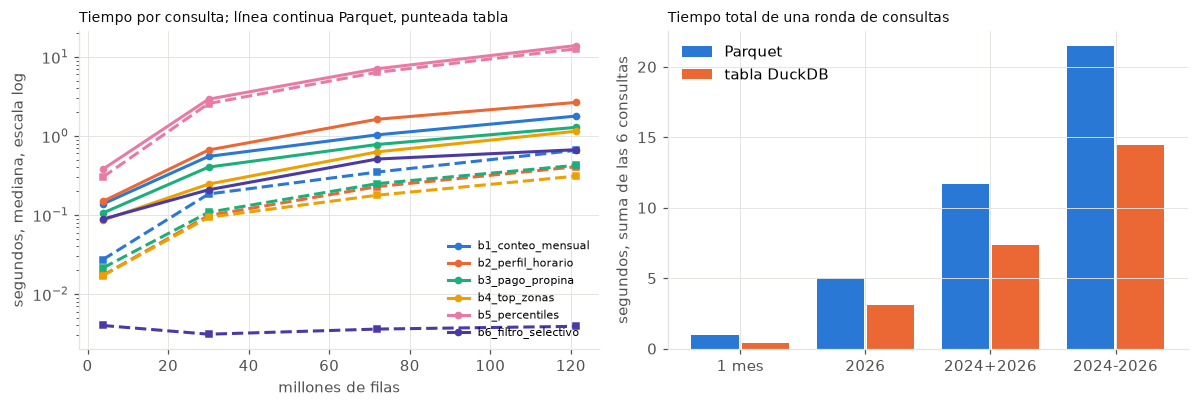

In [50]:
totales_b = mediana.groupby("escala", observed=True)[["parquet", "tabla"]].sum()
totales_b["ahorro_por_ronda_s"] = totales_b.parquet - totales_b.tabla
totales_b = totales_b.join(carga.set_index("escala")[["filas", "segundos_carga"]])
totales_b["rondas_para_amortizar"] = totales_b.segundos_carga / totales_b.ahorro_por_ronda_s
display(totales_b.round(2))

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))
for nombre_c, color in zip(sorted(mediana.consulta.unique()), SERIES + ["#e87ba4", "#4a3aa7"]):
    d = mediana[mediana.consulta == nombre_c]
    ejes[0].plot(d.filas / 1e6, d.parquet, color=color, marker="o", markersize=4, label=nombre_c)
    ejes[0].plot(d.filas / 1e6, d.tabla, color=color, marker="s", markersize=4, linestyle="--")
ejes[0].set_xlabel("millones de filas")
ejes[0].set_ylabel("segundos, mediana, escala log")
ejes[0].set_title("Tiempo por consulta; línea continua Parquet, punteada tabla", loc="left", fontsize=9)
ejes[0].legend(fontsize=7)
ejes[0].set_yscale("log")
x = range(len(totales_b))
ejes[1].bar([i - 0.2 for i in x], totales_b.parquet, width=0.38, color=SERIES[0], label="Parquet")
ejes[1].bar([i + 0.2 for i in x], totales_b.tabla, width=0.38, color=SERIES[1], label="tabla DuckDB")
ejes[1].set_xticks(list(x), totales_b.index)
ejes[1].set_ylabel("segundos, suma de las 6 consultas")
ejes[1].set_title("Tiempo total de una ronda de consultas", loc="left", fontsize=9)
ejes[1].legend()
fig.tight_layout()
guardar(fig, "ej6_benchmark")

### 6.8 Consultas del benchmark

Las seis consultas se listaron en 6.3 y están en sql/benchmark: conteo mensual, perfil horario, pago y propina, top de zonas con join, percentiles y un filtro selectivo de una semana. Los tiempos crudos están en docs/benchmark/tiempos.csv, una fila por ejecución, y el costo de materializar en docs/benchmark/materializacion.csv.

### 6.9 Análisis de resultados

1. La tabla materializada fue más rápida en todas las consultas y escalas. En las agregaciones simples la aceleración está entre 2.6 y 8.6 veces: el perfil horario es la que más gana, entre 6.5 y 8.6 veces, porque calcula expresiones sobre la fecha y filtra por dos columnas.
2. El filtro selectivo es el caso extremo. Sobre la tabla tarda unos 4 milisegundos en cualquier escala, porque los datos quedaron en orden cronológico y DuckDB descarta casi todos los bloques con sus zone maps de mínimos y máximos. Sobre Parquet el tiempo crece de 0.09 a 0.67 segundos, porque debe abrir los metadatos de cada archivo y aplicar el filtro a través de la vista con unión y conversiones. La aceleración pasa de 22 veces con un mes a 172 veces con los tres años.
3. Los percentiles casi no cambian, entre 1.1 y 1.3 veces. Esa consulta está limitada por el cálculo, que debe ordenar millones de valores, y no por la lectura. Cuando el costo es de CPU, el formato de almacenamiento importa poco.
4. Al crecer los datos ambos tiempos crecen aproximadamente en línea con las filas, pero Parquet crece menos de lo proporcional en escalas pequeñas: con 32 veces más filas el conteo mensual tarda 13 veces más, porque hay un costo fijo de abrir archivos y más archivos permiten más paralelismo.
5. La tabla es más rápida porque usa el formato nativo de DuckDB: no hay que decodificar páginas Parquet ni recorrer metadatos en cada consulta, los tipos y nombres ya están homologados sin aplicar la vista, y los zone maps permiten saltar bloques. Parquet tampoco se lee del disco cada vez, porque el sistema operativo lo mantiene en caché; la diferencia medida es de decodificación y no de disco.
6. Materializar tiene un costo: entre 1.9 segundos para un mes y 31 segundos para los tres años, unos 3.9 millones de filas por segundo, y la base ocupa 1.63 veces lo que ocupan los Parquet, 3,265 contra 1,977 MiB. La base completa del laboratorio, ordenada por fecha y con la columna de calidad, tardó cerca de tres minutos y ocupa unos 4 GB. Con el ahorro medido, la carga se recupera después de unas 4 rondas de las seis consultas.

### 6.10 Cuándo usar cada estrategia

Consultar Parquet directamente conviene cuando:

- los datos llegan como archivos nuevos con frecuencia y se quiere consultarlos de inmediato, sin un paso de carga;
- la exploración es puntual o se consulta pocas veces cada archivo;
- los archivos se comparten con otras herramientas como Spark, pandas o un data lake, y duplicarlos sería costoso;
- el espacio en disco es limitado.

Materializar una tabla DuckDB conviene cuando:

- las mismas consultas se repiten muchas veces, como en un tablero que se refresca o un benchmark;
- importa la latencia interactiva, por ejemplo en Metabase;
- hay filtros selectivos frecuentes por columnas con orden natural, como la fecha, que aprovechan los zone maps de la tabla;
- se quieren incorporar transformaciones y reglas de calidad una sola vez, en vez de recalcularlas en cada consulta;
- se necesita una conexión estable y de solo lectura para otras herramientas.

En este laboratorio se combinan ambas: Parquet como fuente de verdad e ingesta incremental, y taxi.duckdb como capa de servicio para los indicadores y el tablero, regenerable en menos de un minuto.

## Ejercicio 7. Construcción de indicadores y visualización

### 7.1 Preguntas de análisis

1. Cómo evoluciona la demanda mensual de cada tipo de taxi
2. Qué peso tienen los taxis verdes en el total y si está cambiando
3. En qué horas se concentra la demanda entre semana y en fin de semana
4. Cuánto paga un pasajero por viaje y cómo cambia en el tiempo
5. Cuánta propina se deja al pagar con tarjeta y si cambia entre meses o tipos
6. Cómo se reparte el método de pago y si el efectivo está desapareciendo
7. A qué horas es más lento moverse en Manhattan y si cambió entre años
8. Qué zonas concentran el origen de los viajes
9. Qué tan dependiente es el servicio de los aeropuertos
10. Qué alcance tiene el cargo por la zona de congestión de Manhattan
11. Qué proporción de registros no es confiable y si eso cambia en el tiempo

### 7.2 y 7.6 Diseño y justificación de los indicadores

| Indicador | Pregunta | Métrica | Visualización | Justificación |
|---|---|---|---|---|
| K1 Viajes válidos | contexto | conteo | número | Da la escala del conjunto analizado |
| K2 Ticket promedio | 4 | promedio de total_amount | número | Resume el ingreso típico por viaje |
| K3 Propina con tarjeta | 5 | suma de propinas sobre suma de tarifas | número | Única propina observable; sirve de referencia |
| I1 Viajes mensuales | 1 | conteo por mes y tipo | líneas, escala log | La escala log permite ver ambos tipos pese a la diferencia de volumen |
| I2 Participación verde | 2 | % de viajes verdes por mes | línea | Mide si el servicio fuera de Manhattan gana o pierde peso |
| I3 Demanda por hora | 3 | viajes por hora por día | líneas por tipo de día | Muestra la diferencia de rutina entre días laborales y fin de semana |
| I4 Ticket mensual | 4 | promedio por mes y tipo | líneas | Captura cambios de tarifa y nuevos cargos |
| I5 Propina mensual | 5 | % propina con tarjeta | líneas | Revela diferencias de comportamiento entre tipos |
| I6 Mezcla de pago | 6 | % de viajes por método y año | barras apiladas al 100 % | Composición de un todo; los años se comparan lado a lado |
| I7 Velocidad Manhattan | 7 | millas sobre horas por hora del día y año | líneas por año | Indicador indirecto de congestión y del efecto del cargo CBD |
| I8 Top zonas | 8 | conteo por zona de origen | barras horizontales | Ranking con nombres largos, se lee mejor en horizontal |
| I9 Aeropuertos | 9 | % de viajes con origen en EWR, JFK o LGA | línea | Los aeropuertos son un mercado estratégico para los taxis amarillos |
| I10 Cargo CBD | 10 | % de viajes con cargo y monto promedio | línea | Mide una política pública nueva directamente en los datos |
| I1b Estacionalidad | 1 | viajes amarillos por día según mes, una línea por año | líneas por año | Compara el mismo mes entre años sin que influya la cantidad de días |
| I11 Calidad | 11 | % de registros descartados por mes y tipo | líneas | Controla que los indicadores no dependan de datos defectuosos |

Todos los indicadores se calculan sobre viajes_limpios_tbl, salvo I11 que usa viajes_tbl completa.

### 7.3 y 7.7 Consultas SQL

Cada indicador es un archivo en sql/indicadores. Su encabezado contiene título, pregunta, tipo de gráfico, dimensiones y métricas, que scripts/metabase_dashboard.py usa para crear la tarjeta de Metabase. El mismo archivo se ejecuta aquí con DuckDB, así el notebook y el tablero muestran exactamente lo mismo. En este punto la base contiene 2024 y 2026.

In [51]:
def leer_indicadores():
    salida = {}
    for ruta in sorted(Path("sql/indicadores").glob("*.sql")):
        meta = {l[3:].split(":", 1)[0].strip(): l[3:].split(":", 1)[1].strip()
                for l in ruta.read_text().splitlines() if l.startswith("-- ") and ":" in l}
        meta["sql"] = ruta.read_text()
        salida[ruta.stem] = meta
    return salida


def calcular_indicadores(etiqueta):
    con_tbl = duckdb.connect(str(DB_TAXI), read_only=True)
    resultados, filas = {}, []
    for clave, ind in leer_indicadores().items():
        inicio = time.perf_counter()
        resultados[clave] = con_tbl.sql(ind["sql"]).df()
        filas.append({"indicador": clave, "titulo": ind["titulo"], "grafico": ind["grafico"],
                      "filas": len(resultados[clave]), "segundos": round(time.perf_counter() - inicio, 3)})
        CATALOGO.append({"consulta": f"indicadores/{clave}", "objetivo": ind["pregunta"],
                         "fuente": f"{DB_TAXI} {etiqueta}", "filas": len(resultados[clave]),
                         "segundos": filas[-1]["segundos"]})
    con_tbl.close()
    display(pd.DataFrame(filas))
    return resultados


ind_2a = calcular_indicadores("2024 y 2026")
print(leer_indicadores()["i07_velocidad_hora"]["sql"])

,indicador,titulo,grafico,filas,segundos
0,i01_viajes_mensuales,Viajes mensuales por tipo de taxi,line,40,1.51
1,i02_participacion_verde,Participacion de taxis verdes en %,line,20,0.48
2,i03_demanda_hora,Viajes promedio por hora del dia,line,48,0.51
3,i04_ticket_mensual,Ticket promedio mensual en USD,line,40,2.12
4,i05_propina_mensual,Propina con tarjeta en % de la tarifa,line,40,1.19
5,i06_mezcla_pago,Metodo de pago por anio en %,bar,8,0.56
6,i07_velocidad_hora,"Velocidad promedio por hora en mph, origen Man...",line,48,2.31
7,i08_top_zonas,Diez zonas con mas viajes de origen,row,10,0.39
8,i09_aeropuertos,Viajes con origen en aeropuertos en %,line,20,0.51
9,i10_cargo_cbd,Viajes con cargo de congestion CBD en %,line,20,0.62


-- titulo: Velocidad promedio por hora en mph, origen Manhattan
-- pregunta: Cuando es mas lento moverse en Manhattan y cambio entre anios
-- grafico: line
-- dimensiones: hora, anio
-- metricas: mph
SELECT hour(v.pickup) AS hora,
       year(v.pickup)::VARCHAR AS anio,
       round(sum(v.trip_distance) / sum(v.duracion_min / 60), 2) AS mph
FROM viajes_limpios_tbl v
JOIN zonas z ON v.pu_location_id = z.location_id
WHERE z.borough = 'Manhattan'
GROUP BY ALL
ORDER BY anio, hora;



### 7.4 y 7.5 Visualizaciones y tablero

La herramienta proporcionada es Metabase. scripts/metabase_dashboard.py crea el usuario administrador local, registra taxi.duckdb en modo solo lectura, crea una pregunta nativa por cada archivo de sql/indicadores y arma el tablero Taxis NYC 2024-2026 en http://127.0.0.1:3000. Abajo se reproduce el mismo tablero con matplotlib para dejarlo dentro del notebook; la captura del tablero de Metabase se muestra en el ejercicio 8, ya con los tres años.

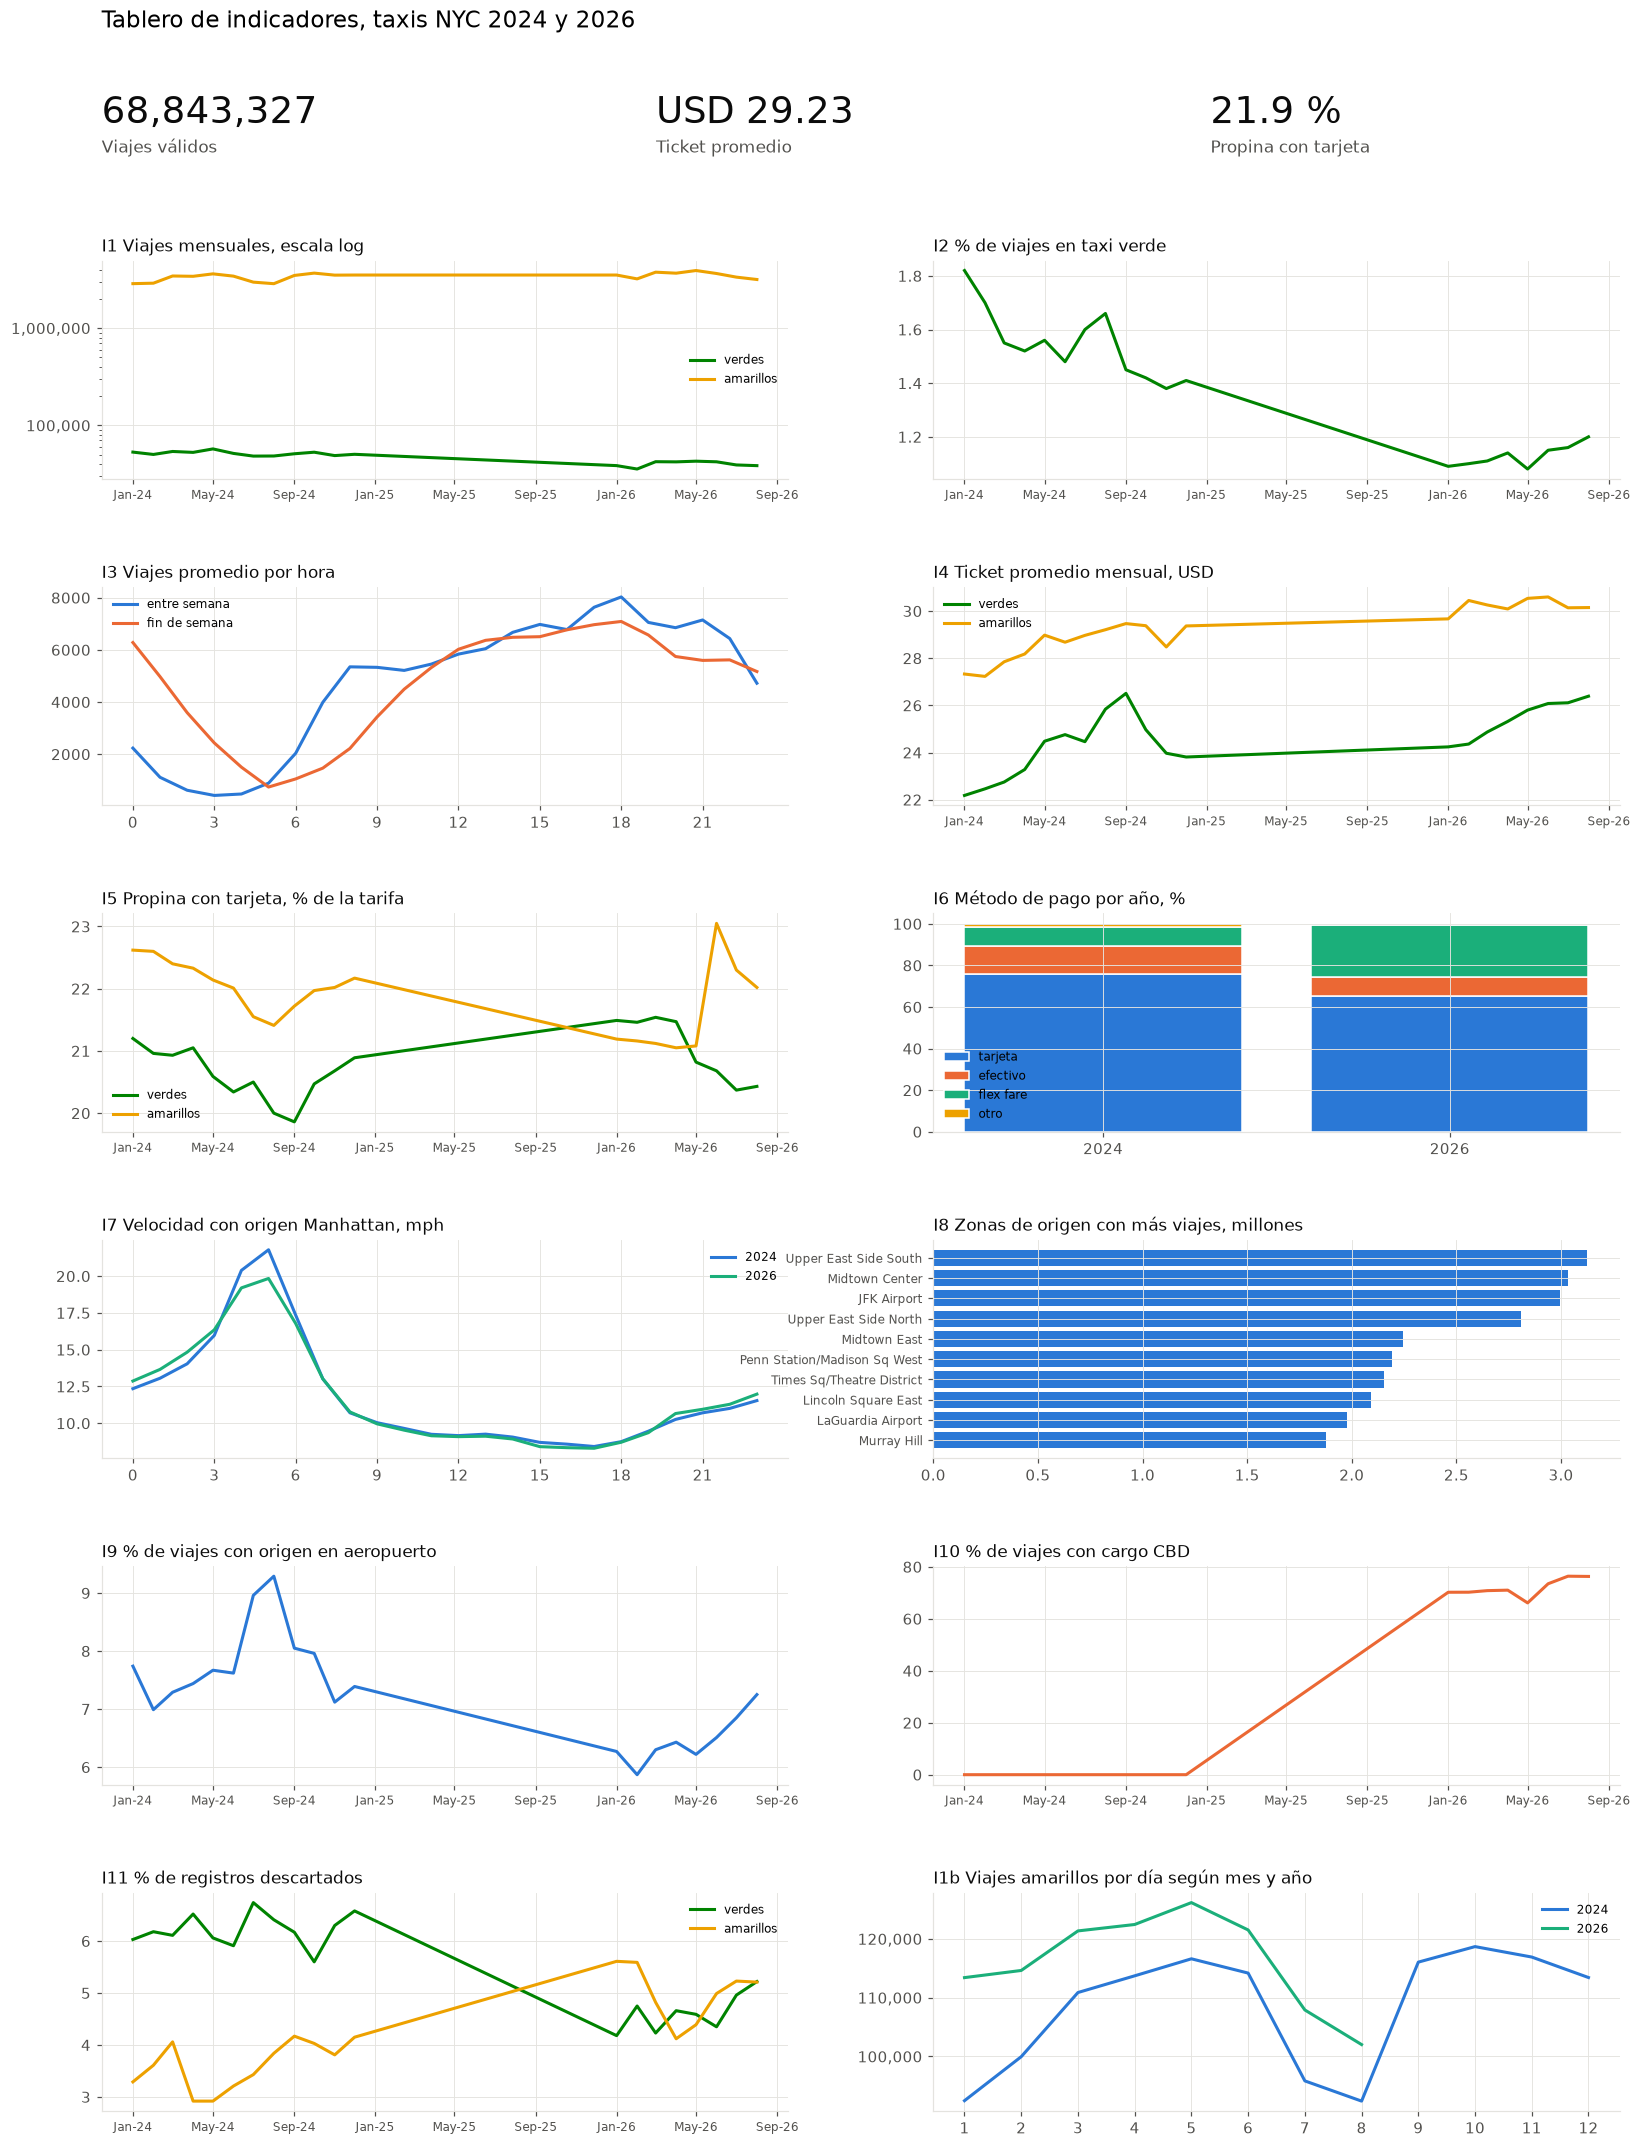

In [52]:
def etiqueta_taxi(t):
    return "amarillos" if t == "yellow" else "verdes"


def linea_por(eje, df, x, y, serie, colores, nombres=None):
    for valor, d in df.groupby(serie):
        eje.plot(d[x], d[y], color=colores[str(valor)], label=(nombres or str)(valor))


def tablero(ind, titulo, nombre):
    fig = plt.figure(figsize=(15, 20))
    rejilla = fig.add_gridspec(7, 6, height_ratios=[0.3, 1, 1, 1, 1, 1, 1], hspace=0.55, wspace=1.1,
                               top=0.95, bottom=0.03, left=0.06, right=0.98)
    kpis = [("k01_viajes_validos", "viajes", "Viajes válidos", "{:,.0f}"),
            ("k02_ticket_promedio", "ticket_promedio", "Ticket promedio", "USD {:,.2f}"),
            ("k03_propina_tarjeta", "pct_propina", "Propina con tarjeta", "{:.1f} %")]
    for i, (clave, col, texto, fmt) in enumerate(kpis):
        eje = fig.add_subplot(rejilla[0, i * 2:(i + 1) * 2])
        eje.axis("off")
        eje.text(0, 0.45, fmt.format(ind[clave][col].iloc[0]), fontsize=24, color=TINTA)
        eje.text(0, 0.0, texto, fontsize=11, color=TINTA_2)
    ejes = [fig.add_subplot(rejilla[1 + i // 2, (i % 2) * 3:(i % 2) * 3 + 3]) for i in range(12)]

    linea_por(ejes[0], ind["i01_viajes_mensuales"], "mes", "viajes", "taxi", COLOR_TAXI, etiqueta_taxi)
    ejes[0].set_yscale("log"); ejes[0].set_title("I1 Viajes mensuales, escala log", loc="left")
    d = ind["i02_participacion_verde"]
    ejes[1].plot(d.mes, d.pct_verdes, color=COLOR_TAXI["green"]); ejes[1].set_title("I2 % de viajes en taxi verde", loc="left")
    d = ind["i03_demanda_hora"]
    linea_por(ejes[2], d, "hora", "viajes_por_dia", "tipo_dia", {"entre semana": SERIES[0], "fin de semana": SERIES[1]})
    ejes[2].set_title("I3 Viajes promedio por hora", loc="left"); ejes[2].set_xticks(range(0, 24, 3))
    linea_por(ejes[3], ind["i04_ticket_mensual"], "mes", "ticket_promedio", "taxi", COLOR_TAXI, etiqueta_taxi)
    ejes[3].set_title("I4 Ticket promedio mensual, USD", loc="left")
    linea_por(ejes[4], ind["i05_propina_mensual"], "mes", "pct_propina", "taxi", COLOR_TAXI, etiqueta_taxi)
    ejes[4].set_title("I5 Propina con tarjeta, % de la tarifa", loc="left")
    d = ind["i06_mezcla_pago"].pivot(index="anio", columns="metodo", values="pct_viajes").fillna(0)
    base = pd.Series(0.0, index=d.index)
    for metodo, color in zip(["tarjeta", "efectivo", "flex fare", "otro"], SERIES):
        if metodo in d:
            ejes[5].bar(d.index, d[metodo], bottom=base, color=color, label=metodo, edgecolor="white", linewidth=1)
            base += d[metodo]
    ejes[5].set_title("I6 Método de pago por año, %", loc="left")
    linea_por(ejes[6], ind["i07_velocidad_hora"], "hora", "mph", "anio", COLOR_ANIO)
    ejes[6].set_title("I7 Velocidad con origen Manhattan, mph", loc="left"); ejes[6].set_xticks(range(0, 24, 3))
    d = ind["i08_top_zonas"].iloc[::-1]
    ejes[7].barh(d.zona.str.replace("Manhattan - ", "").str.replace("Queens - ", ""), d.viajes / 1e6, color=SERIES[0])
    ejes[7].set_title("I8 Zonas de origen con más viajes, millones", loc="left"); ejes[7].tick_params(axis="y", labelsize=8)
    d = ind["i09_aeropuertos"]
    ejes[8].plot(d.mes, d.pct_aeropuerto, color=SERIES[0]); ejes[8].set_title("I9 % de viajes con origen en aeropuerto", loc="left")
    d = ind["i10_cargo_cbd"]
    ejes[9].plot(d.mes, d.pct_con_cargo, color=SERIES[1]); ejes[9].set_title("I10 % de viajes con cargo CBD", loc="left")
    linea_por(ejes[10], ind["i11_calidad_mensual"], "mes", "pct_descartados", "taxi", COLOR_TAXI, etiqueta_taxi)
    ejes[10].set_title("I11 % de registros descartados", loc="left")
    d = ind["i01_viajes_mensuales"].query("taxi == 'yellow'").copy()
    d["anio"], d["num_mes"] = d.mes.dt.year.astype(str), d.mes.dt.month
    d["viajes_por_dia"] = d.viajes / d.mes.dt.days_in_month
    linea_por(ejes[11], d, "num_mes", "viajes_por_dia", "anio", COLOR_ANIO)
    ejes[11].set_title("I1b Viajes amarillos por día según mes y año", loc="left")
    ejes[11].set_xticks(range(1, 13)); ejes[11].yaxis.set_major_formatter(miles)
    for i, eje in enumerate(ejes):
        if eje.get_legend_handles_labels()[0] and i != 7:
            eje.legend(fontsize=8, loc="upper right" if i == 6 else "best")
        if i in (0, 1, 3, 4, 8, 9, 10):
            eje.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
            eje.tick_params(axis="x", labelsize=8)
    ejes[0].yaxis.set_major_formatter(miles)
    fig.suptitle(titulo, x=0.06, ha="left", fontsize=15, y=0.985)
    guardar(fig, nombre)


tablero(ind_2a, "Tablero de indicadores, taxis NYC 2024 y 2026", "ej7_tablero_2024_2026")

In [53]:
mb = subprocess.run([sys.executable, "scripts/metabase_dashboard.py"], capture_output=True, text=True)
print(mb.stdout[-2500:], mb.stderr[-1500:])

  la base cambio, se refresca la conexion
  i01_viajes_mensuales       tarjeta  40  completed  filas=40
  i02_participacion_verde    tarjeta  41  completed  filas=20
  i03_demanda_hora           tarjeta  42  completed  filas=48
  i04_ticket_mensual         tarjeta  43  completed  filas=40
  i05_propina_mensual        tarjeta  44  completed  filas=40
  i06_mezcla_pago            tarjeta  45  completed  filas=8
  i07_velocidad_hora         tarjeta  46  completed  filas=48
  i08_top_zonas              tarjeta  47  completed  filas=10
  i09_aeropuertos            tarjeta  48  completed  filas=20
  i10_cargo_cbd              tarjeta  49  completed  filas=20
  i11_calidad_mensual        tarjeta  50  completed  filas=40
  k01_viajes_validos         tarjeta  51  completed  filas=1
  k02_ticket_promedio        tarjeta  52  completed  filas=1
  k03_propina_tarjeta        tarjeta  53  completed  filas=1

Tablero  : http://127.0.0.1:3000/dashboard/2
Publico  : http://127.0.0.1:3000/public/dashboar

### 7.8 Interpretación de los indicadores

Interpretación con 2024 y 2026:

- K1 a K3: la base de servicio tiene cerca de 69 millones de viajes válidos, con un ticket promedio cercano a 29 dólares y una propina con tarjeta cercana al 22 % de la tarifa.
- I1 y I1b: la demanda amarilla es mayor en 2026 que en 2024 en todos los meses comparables, con el pico de cada año en mayo y los mínimos en enero y febrero. La escala logarítmica permite ver en el mismo gráfico que los verdes están por debajo de 2024 en todos los meses de 2026, al contrario que los amarillos.
- I2: la participación verde baja de cerca de 1.6 % en 2024 a 1.1 % en 2026. Pierde peso aunque el sistema total crece.
- I3: entre semana hay un pico a las 18h y un hueco en la madrugada; el fin de semana la madrugada concentra varias veces más viajes y la mañana es más lenta.
- I4: el ticket amarillo sube de alrededor de 28.6 a 30.2 dólares. Parte del aumento coincide con el cargo CBD de 0.75 que no existía en 2024.
- I5: la propina con tarjeta es casi constante, entre 21 % y 23 % en amarillos y unos puntos menor en verdes. Es un comportamiento muy estable del pasajero.
- I6: el pago con tarjeta baja de 75.9 % a 65.4 % y Flex Fare sube de 9.2 % a 24.7 %, mientras el efectivo cae de 13.5 % a 9.2 %. El cambio no es hacia el efectivo, sino hacia viajes con precio fijo pedidos por app.
- I7: en Manhattan la velocidad mínima, cerca de 8.3 mph a las 17h, es casi igual en ambos años; las diferencias están en la madrugada.
- I8: los orígenes se concentran en el Upper East Side, Midtown y los aeropuertos JFK y LaGuardia, que son a la vez zonas residenciales de alto ingreso, de oficinas y de viajeros.
- I9: el peso de los aeropuertos baja de cerca de 7.8 % a 6.5 %.
- I10: el cargo CBD no existe en 2024 y en 2026 lo paga alrededor del 72 % de los viajes. Es siempre de 0.75 dólares, la tarifa fija para taxis.
- I11: los registros descartados están entre 3 % y 7 % según el mes y el tipo, así que los indicadores se apoyan en más del 93 % de los datos.

## Ejercicio 8. Incorporación de datos de 2025 y análisis completo

### 8.1 y 8.2 Descarga

Se ejecuta el script sin argumentos, que por defecto incluye 2024, 2025 y 2026. La ejecución original quedó en docs/logs/descarga_2024_2025_2026.txt.

In [54]:
log = Path("docs/logs/descarga_2024_2025_2026.txt").read_text().splitlines()
print("Registro original:", sum("listo (" in l for l in log), "descargados de 2025 y",
      sum("ya existe" in l for l in log), "omitidos de 2024 y 2026")
manifiesto = descargar()
display(manifiesto.groupby(["tipo", "anio"])
        .agg(archivos=("mes", "count"), registros=("registros", "sum"),
             tamanio_ok=("tamanio_ok", "all"), legibles=("parquet_legible", "all"))
        .reset_index())

Registro original: 24 descargados de 2025 y 41 omitidos de 2024 y 2026


Archivos omitidos por existir: 65 | descargados ahora: 0
RESUMEN
  anios         : 2024, 2025, 2026
  descargados   : 0
  ya existian   : 64
  no publicados : 4
      yellow 2026-09, yellow 2026-10, green 2026-09, green 2026-10
  fallidos      : 0
  archivos locales validados : 64
  registros totales          : 121,184,384
  archivos con problemas     : 0
  manifiesto                 : docs/manifest_descargas.csv


,tipo,anio,archivos,registros,tamanio_ok,legibles
0,green,2024,12,660218,True,True
1,green,2025,12,591375,True,True
2,green,2026,8,337114,True,True
3,yellow,2024,12,41169720,True,True
4,yellow,2025,12,48722602,True,True
5,yellow,2026,8,29703355,True,True


### 8.3 Las consultas siguen funcionando

In [55]:
usar_anios([2024, 2025, 2026])
estado = pd.concat([reejecutar("sql/ejercicio4").assign(carpeta="ejercicio4"),
                    reejecutar("sql/ejercicio5").assign(carpeta="ejercicio5")])
display(estado)
print("Consultas con error:", (estado.estado != "ok").sum())

Vistas creadas para [2024, 2025, 2026]


,consulta,estado,filas,segundos,carpeta
0,00_clasificacion_calidad.sql,ok,17,5.17,ejercicio4
1,p1_dias_extremos.sql,ok,10,5.23,ejercicio4
2,p1_viajes_diarios.sql,ok,1948,5.03,ejercicio4
3,p1_viajes_mensuales.sql,ok,24,5.16,ejercicio4
4,p2_hora_dia_semana.sql,ok,168,5.03,ejercicio4
5,p3_histograma_distancia.sql,ok,82,5.20,ejercicio4
6,p3_percentiles.sql,ok,8,38.87,ejercicio4
7,p4_borough_origen.sql,ok,16,5.48,ejercicio4
8,p4_comparacion_tipos.sql,ok,2,11.40,ejercicio4
9,p5_distribucion_propina.sql,ok,7,5.53,ejercicio4


Consultas con error: 0


Las 21 consultas de los ejercicios 4 y 5 se ejecutan sin cambios sobre los tres años. La única que pierde sentido es ejercicio5/04_continuidad_mensual, que compara columnas fijas de 2024 y 2026; sigue funcionando pero no muestra 2025, por eso se generaliza abajo en 8.7.

### 8.4 Indicadores y tablero con los tres años

Se reconstruye taxi.duckdb con los tres años y se recalculan los mismos archivos de sql/indicadores. No se modificó ninguna consulta de indicador.

,db,anios,filas,segundos,mib,mib_parquet
0,data/processed/taxi.duckdb,"[2024, 2026]",71870407,86.50,"2,348.00","1,171.70"
1,data/processed/taxi.duckdb,"[2024, 2025, 2026]",121184384,161.10,"4,010.00","1,977.00"


,indicador,titulo,grafico,filas,segundos
0,i01_viajes_mensuales,Viajes mensuales por tipo de taxi,line,64,2.74
1,i02_participacion_verde,Participacion de taxis verdes en %,line,32,0.96
2,i03_demanda_hora,Viajes promedio por hora del dia,line,48,0.85
3,i04_ticket_mensual,Ticket promedio mensual en USD,line,64,1.47
4,i05_propina_mensual,Propina con tarjeta en % de la tarifa,line,64,2.54
5,i06_mezcla_pago,Metodo de pago por anio en %,bar,12,1.18
6,i07_velocidad_hora,"Velocidad promedio por hora en mph, origen Man...",line,72,3.37
7,i08_top_zonas,Diez zonas con mas viajes de origen,row,10,0.64
8,i09_aeropuertos,Viajes con origen en aeropuertos en %,line,32,0.67
9,i10_cargo_cbd,Viajes con cargo de congestion CBD en %,line,32,1.03


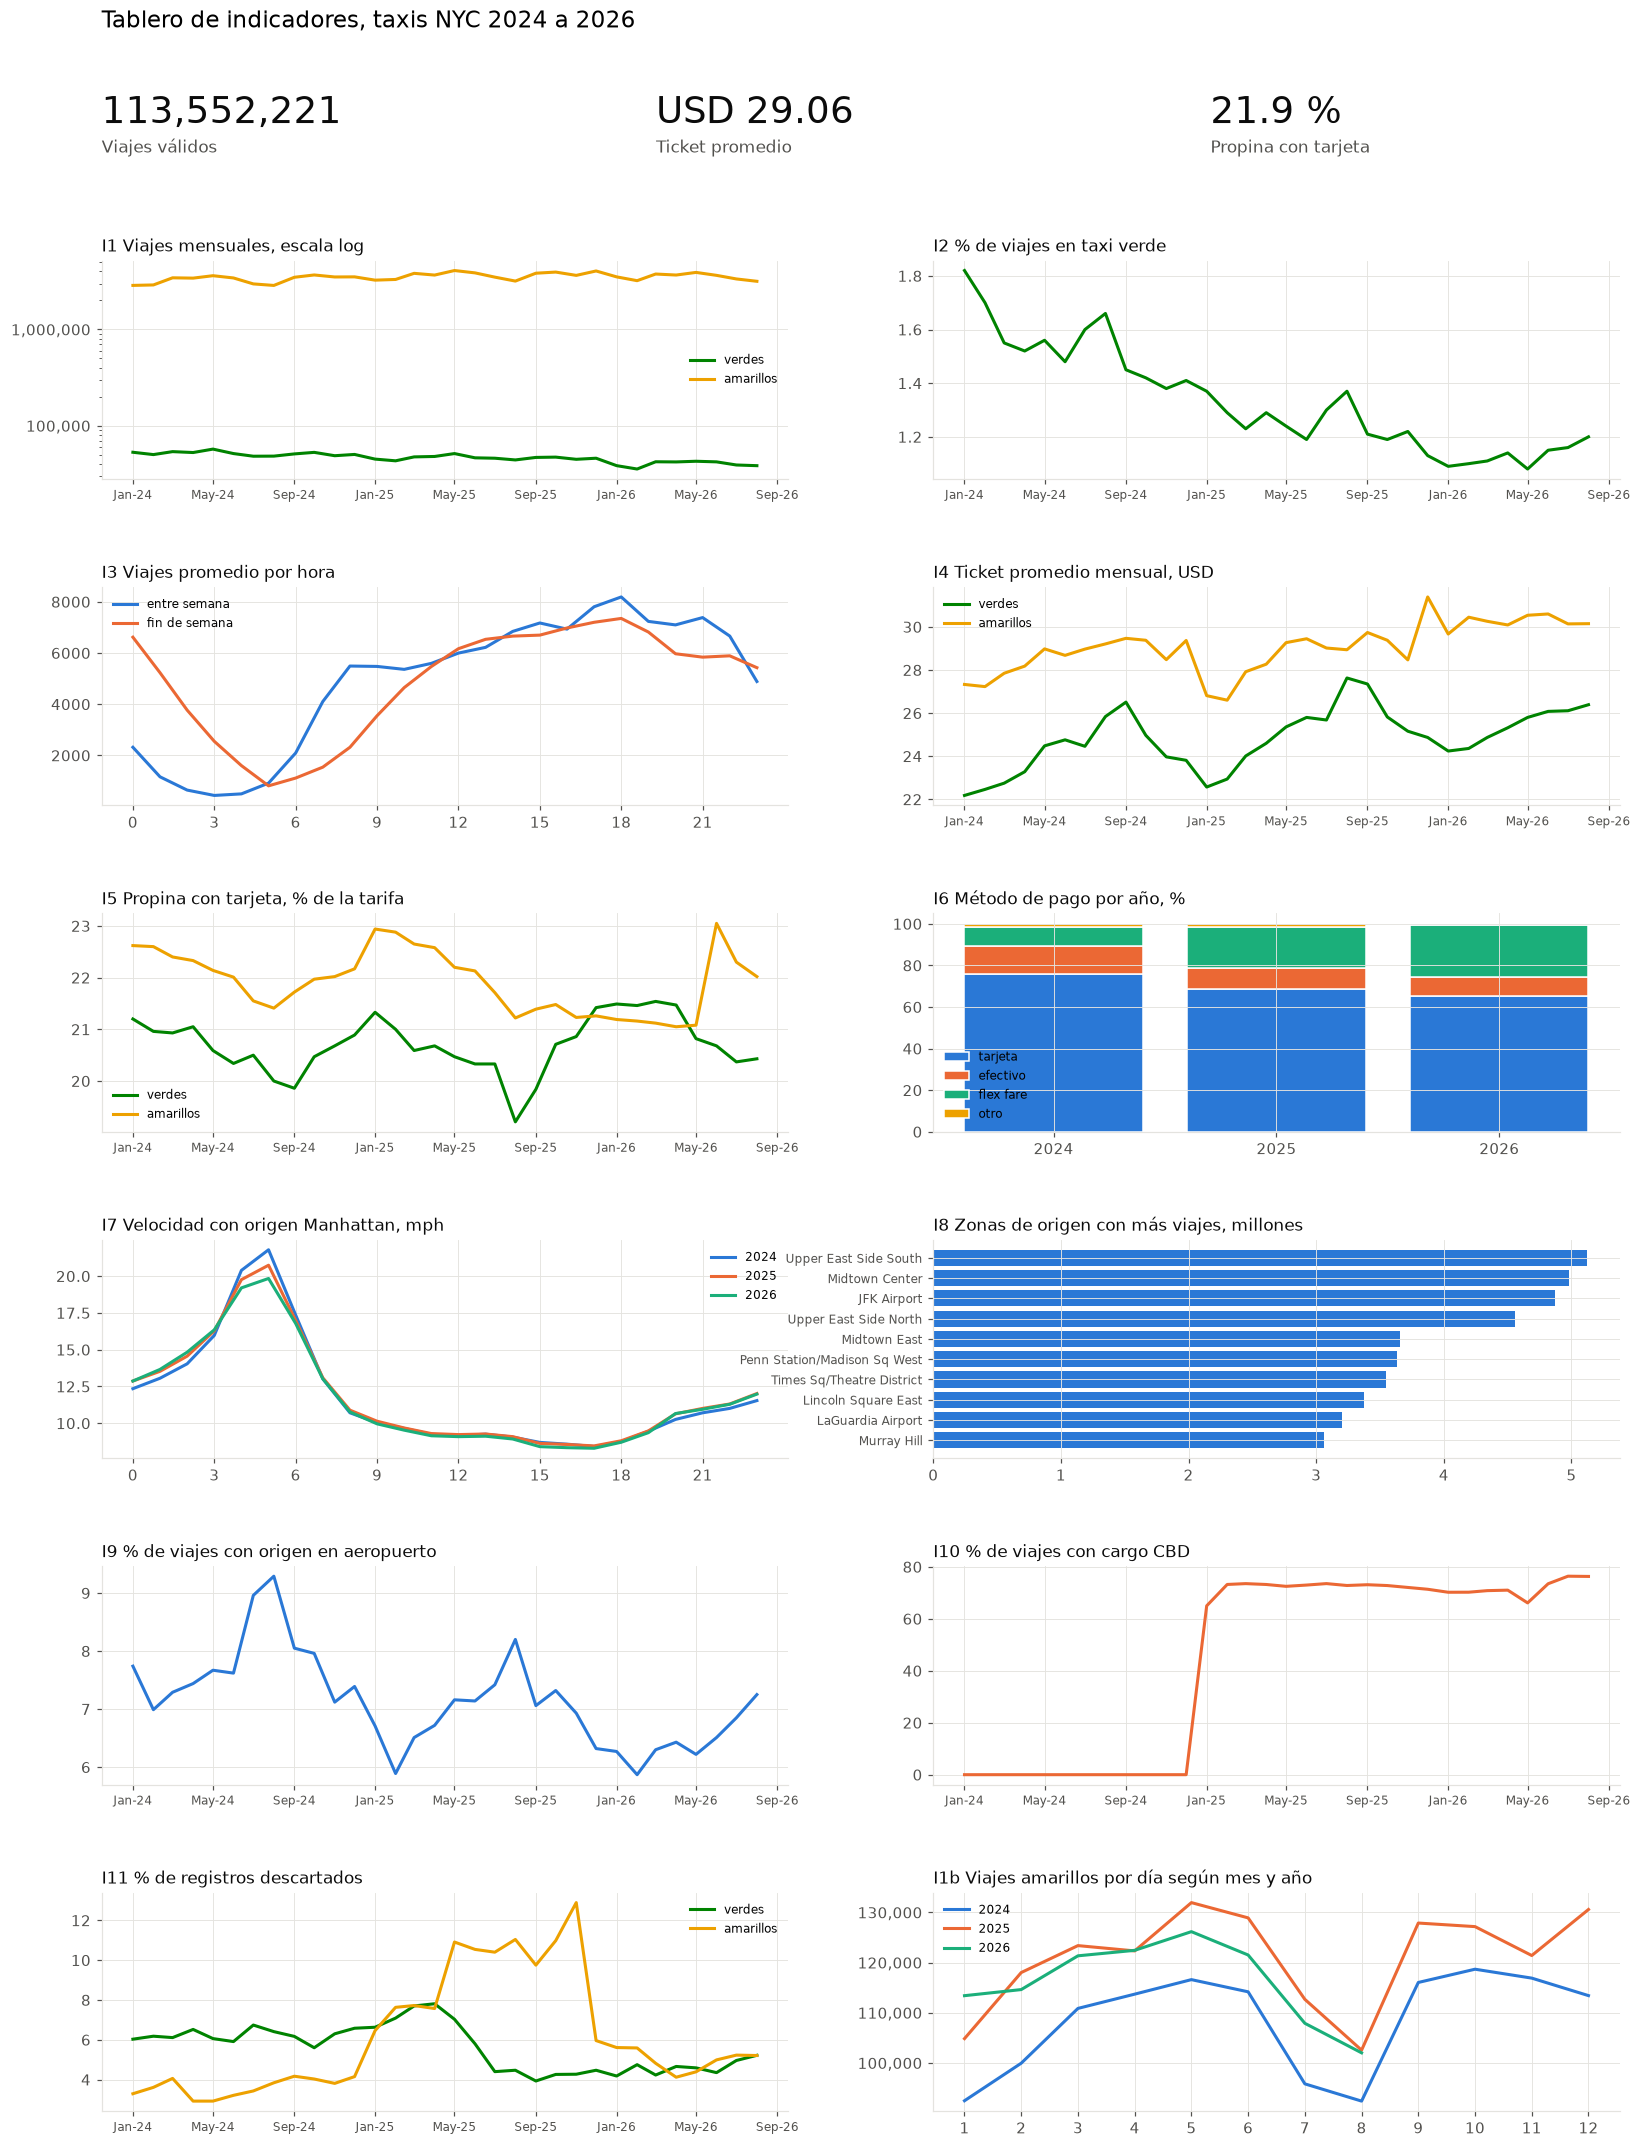

In [56]:
materializacion_3a = taxi_db.materializar(DB_TAXI, [2024, 2025, 2026])
materializacion_3a["mib_parquet"] = round(manifiesto.bytes_local.sum() / 2**20, 1)
display(pd.DataFrame([materializacion_2a, materializacion_3a]))
ind_3a = calcular_indicadores("2024, 2025 y 2026")
tablero(ind_3a, "Tablero de indicadores, taxis NYC 2024 a 2026", "ej8_tablero_2024_2026")

In [57]:
mb = subprocess.run([sys.executable, "scripts/metabase_dashboard.py"], capture_output=True, text=True)
print(mb.stdout[-2500:], mb.stderr[-1500:])

  la base cambio, se refresca la conexion
  i01_viajes_mensuales       tarjeta  40  completed  filas=64
  i02_participacion_verde    tarjeta  41  completed  filas=32
  i03_demanda_hora           tarjeta  42  completed  filas=48
  i04_ticket_mensual         tarjeta  43  completed  filas=64
  i05_propina_mensual        tarjeta  44  completed  filas=64
  i06_mezcla_pago            tarjeta  45  completed  filas=12
  i07_velocidad_hora         tarjeta  46  completed  filas=72
  i08_top_zonas              tarjeta  47  completed  filas=10
  i09_aeropuertos            tarjeta  48  completed  filas=32
  i10_cargo_cbd              tarjeta  49  completed  filas=32
  i11_calidad_mensual        tarjeta  50  completed  filas=64
  k01_viajes_validos         tarjeta  51  completed  filas=1
  k02_ticket_promedio        tarjeta  52  completed  filas=1
  k03_propina_tarjeta        tarjeta  53  completed  filas=1

Tablero  : http://127.0.0.1:3000/dashboard/2
Publico  : http://127.0.0.1:3000/public/dashboa

El tablero de Metabase lee data/processed/taxi.duckdb. Al reconstruir la base, las tarjetas muestran los tres años sin editar ninguna pregunta: el script detecta que el archivo cambió y Metabase abre una conexión nueva. En la salida anterior las mismas tarjetas pasan de 40 a 64 filas en I1, porque ahora hay 32 meses en lugar de 20.

Captura del tablero publicado en Metabase, tomada con Edge sin interfaz mediante python scripts/metabase_dashboard.py --url http://127.0.0.1:3000 --capturas:

![Tablero Taxis NYC 2024-2026 en Metabase](../docs/figuras/tablero_metabase.png)

### 8.5 Evolución de los indicadores en el tiempo

Para comparar años de forma justa se usan solo enero a agosto, los meses disponibles en los tres años.

In [58]:
evolucion = consulta("ejercicio8/01_evolucion_anual", "Indicadores clave por año en enero a agosto", """
    SELECT year(pickup) AS anio,
           count(*) AS viajes,
           round(count(*) / count(DISTINCT pickup::DATE)) AS viajes_por_dia,
           round(100.0 * count_if(taxi = 'green') / count(*), 2) AS pct_verdes,
           round(avg(total_amount), 2) AS ticket_prom,
           round(avg(fare_amount), 2) AS tarifa_prom,
           round(avg(trip_distance), 2) AS distancia_prom,
           round(100.0 * sum(tip_amount) FILTER (WHERE payment_type = 1)
                 / sum(fare_amount) FILTER (WHERE payment_type = 1), 2) AS pct_propina_tarjeta,
           round(100.0 * count_if(payment_type = 2) / count(*), 2) AS pct_efectivo,
           round(100.0 * count_if(payment_type = 0) / count(*), 2) AS pct_flex_fare,
           round(100.0 * count_if(pu_location_id IN (1, 132, 138)) / count(*), 2) AS pct_aeropuerto,
           round(100.0 * count_if(coalesce(cbd_congestion_fee, 0) > 0) / count(*), 2) AS pct_cargo_cbd,
           round(sum(coalesce(cbd_congestion_fee, 0)) / 1e6, 2) AS cbd_recaudado_musd
    FROM viajes_limpios
    WHERE mes_archivo <= 8
    GROUP BY anio
    ORDER BY anio
""")
variacion = evolucion.set_index("anio").pct_change().mul(100).round(1).iloc[1:]
print("Variación porcentual contra el año anterior")
display(variacion)

[sql/ejercicio8/01_evolucion_anual.sql]  3 filas en 5.94 s
Objetivo: Indicadores clave por año en enero a agosto
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2025,2026}/*.parquet


,anio,viajes,viajes_por_dia,pct_verdes,ticket_prom,tarifa_prom,distancia_prom,pct_propina_tarjeta,pct_efectivo,pct_flex_fare,pct_aeropuerto,pct_cargo_cbd,cbd_recaudado_musd
0,2024,25907420,"106,178.00",1.60,28.25,19.50,3.41,22.11,14.01,8.85,7.85,0.00,0.00
1,2025,29053823,"119,563.00",1.28,28.29,19.55,3.45,22.27,10.17,19.36,6.96,72.19,15.73
2,2026,28547853,"117,481.00",1.13,30.19,21.24,3.51,21.59,9.18,24.66,6.45,71.68,15.35


Variación porcentual contra el año anterior


,viajes,viajes_por_dia,pct_verdes,ticket_prom,tarifa_prom,distancia_prom,pct_propina_tarjeta,pct_efectivo,pct_flex_fare,pct_aeropuerto,pct_cargo_cbd,cbd_recaudado_musd
anio,,,,,,,,,,,,
2025,12.10,12.60,-20.00,0.10,0.30,1.20,0.70,-27.40,118.80,-11.30,inf,inf
2026,-1.70,-1.70,-11.70,6.70,8.60,1.70,-3.10,-9.70,27.40,-7.30,-0.70,-2.40


[sql/ejercicio8/02_viajes_mes_anio.sql]  64 filas en 5.35 s
Objetivo: Viajes por día según mes y año para comparar estacionalidad
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2025,2026}/*.parquet


[sql/ejercicio8/03_continuidad_mensual.sql]  12 filas en 0.97 s
Objetivo: Archivos con datos por mes, tipo y año
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2025,2026}/*.parquet


,mes_archivo,green_2024,green_2025,green_2026,yellow_2024,yellow_2025,yellow_2026
0,1,56551,48326,40272,2964624,3475226,3724889
1,2,53577,46621,37373,3007526,3577543,3399866
2,3,57457,51539,44208,3582628,4145257,3952451
3,4,56471,52132,44238,3514289,3970553,3831240
4,5,61003,55399,44921,3723833,4591845,4090836
5,6,54748,49390,44163,3539193,4322960,3837248
6,7,51837,48205,41252,3076903,3898963,3530109
7,8,51771,46306,40687,2979183,3574091,3336716
8,9,54440,48893,0,3633030,4251015,0
9,10,56147,49416,0,3833771,4428699,0


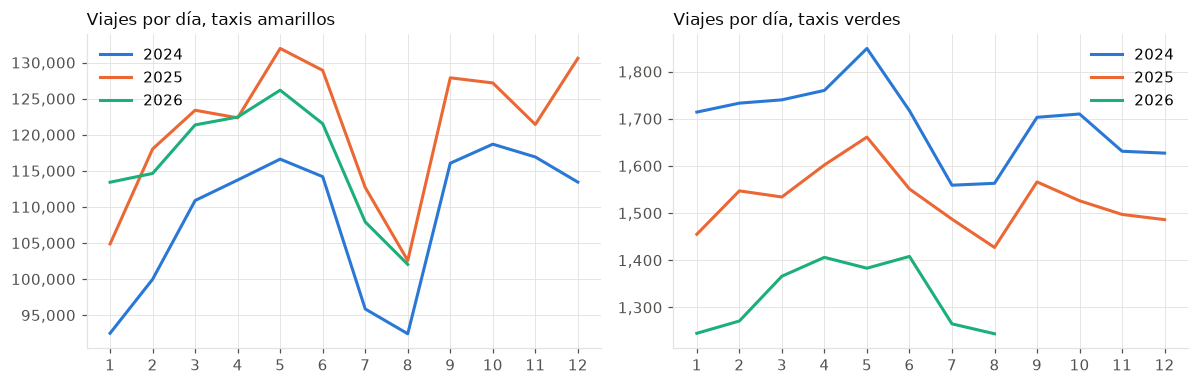

In [59]:
mensual_3a = consulta("ejercicio8/02_viajes_mes_anio", "Viajes por día según mes y año para comparar estacionalidad", """
    SELECT year(pickup)::VARCHAR AS anio, month(pickup) AS mes, taxi,
           round(count(*) / count(DISTINCT pickup::DATE)) AS viajes_por_dia
    FROM viajes_limpios
    GROUP BY ALL
    ORDER BY anio, mes
""", mostrar=False)
continuidad_3a = consulta("ejercicio8/03_continuidad_mensual", "Archivos con datos por mes, tipo y año", """
    SELECT * FROM (
        PIVOT (SELECT anio_archivo, mes_archivo, taxi FROM viajes)
        ON taxi || '_' || anio_archivo USING count(*)
    )
    ORDER BY mes_archivo
""")

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6))
for eje, taxi in zip(ejes, ["yellow", "green"]):
    linea_por(eje, mensual_3a[mensual_3a.taxi == taxi], "mes", "viajes_por_dia", "anio", COLOR_ANIO)
    eje.set_title(f"Viajes por día, taxis {etiqueta_taxi(taxi)}", loc="left")
    eje.set_xticks(range(1, 13))
    eje.yaxis.set_major_formatter(miles)
    eje.legend()
fig.tight_layout()
guardar(fig, "ej8_estacionalidad")

In [60]:
manhattan = consulta("ejercicio8/04_velocidad_cbd", "Velocidad y duración de viajes que entran o salen de Manhattan bajo la calle 60", """
    WITH z AS (SELECT location_id FROM read_csv('data/raw/zones/taxi_zone_lookup.csv', header = true)
                    t(location_id, borough, zona, service_zone)
               WHERE borough = 'Manhattan' AND zona NOT IN (
                   'Central Harlem', 'Central Harlem North', 'East Harlem North', 'East Harlem South',
                   'Hamilton Heights', 'Inwood', 'Inwood Hill Park', 'Manhattanville', 'Morningside Heights',
                   'Washington Heights North', 'Washington Heights South', 'Upper West Side North',
                   'Upper West Side South', 'Upper East Side North', 'Upper East Side South',
                   'Lincoln Square East', 'Lincoln Square West', 'Bloomingdale', 'Yorkville East', 'Yorkville West',
                   'Central Park', 'Randalls Island', 'Marble Hill', 'Highbridge Park', 'Lenox Hill East',
                   'Lenox Hill West', 'Roosevelt Island'))
    SELECT year(pickup) AS anio,
           CASE WHEN hour(pickup) BETWEEN 7 AND 19 AND isodow(pickup) <= 5 THEN 'laboral 7 a 19h' ELSE 'resto' END AS franja,
           count(*) AS viajes,
           round(sum(trip_distance) / sum(duracion_min / 60), 2) AS mph,
           round(median(duracion_min), 1) AS duracion_mediana
    FROM viajes_limpios
    WHERE taxi = 'yellow' AND mes_archivo <= 8
      AND pu_location_id IN (SELECT location_id FROM z) AND do_location_id IN (SELECT location_id FROM z)
    GROUP BY ALL
    ORDER BY franja, anio
""")

[sql/ejercicio8/04_velocidad_cbd.sql]  6 filas en 6.28 s
Objetivo: Velocidad y duración de viajes que entran o salen de Manhattan bajo la calle 60
Fuente: vistas de sql/01_vistas.sql sobre data/raw/{yellow,green}/{2024,2025,2026}/*.parquet


,anio,franja,viajes,mph,duracion_mediana
0,2024,laboral 7 a 19h,5304880,7.43,11.90
1,2025,laboral 7 a 19h,5634621,7.48,11.90
2,2026,laboral 7 a 19h,5143424,6.90,12.80
3,2024,resto,5458086,9.19,10.20
4,2025,resto,6289130,9.44,10.40
5,2026,resto,6026989,8.86,11.20


Comparando enero a agosto de cada año:

| Indicador | 2024 | 2025 | 2026 |
|---|---|---|---|
| Viajes válidos | 25.9 M | 29.1 M | 28.5 M |
| Viajes por día | 106,178 | 119,563 | 117,481 |
| % de viajes en taxi verde | 1.60 | 1.28 | 1.13 |
| Ticket promedio en USD | 28.25 | 28.29 | 30.19 |
| Tarifa promedio en USD | 19.50 | 19.55 | 21.24 |
| Distancia promedio en millas | 3.41 | 3.45 | 3.51 |
| Propina con tarjeta, % de la tarifa | 22.11 | 22.27 | 21.59 |
| % efectivo | 14.01 | 10.17 | 9.18 |
| % Flex Fare | 8.85 | 19.36 | 24.66 |
| % con origen en aeropuerto | 7.85 | 6.96 | 6.45 |
| % con cargo CBD | 0 | 72.19 | 71.68 |
| Cargo CBD cobrado, millones de USD | 0 | 15.73 | 15.35 |
| Velocidad dentro de la zona CBD, laboral 7 a 19h, mph | 7.43 | 7.48 | 6.90 |
| Duración mediana dentro de la zona CBD, laboral, min | 11.9 | 11.9 | 12.8 |

La estacionalidad se repite en los tres años, con el pico en mayo y los mínimos en enero, febrero y agosto, pero 2025 está por encima de 2024 en todos los meses y 2026 queda entre ambos. El indicador de calidad muestra un salto en los amarillos de 2025, con meses de hasta 12.9 % de descartes, que corresponde a la entrada de Helix: sus 535,901 registros de 2025 tienen duración cero.

### 8.6 Cambios y patrones visibles con los tres años

1. Rebote y estancamiento de la demanda. Los viajes válidos de enero a agosto crecen 12.1 % de 2024 a 2025 y caen 1.7 % en 2026. Sin el año intermedio parecería un crecimiento continuo de 2024 a 2026; con los tres años se ve que el crecimiento ocurrió en 2025 y que 2026 se estabilizó. El salto de 2025 coincide con el inicio del cobro por congestión, que encareció el uso del auto particular en el centro, aunque con estos datos no se puede afirmar que sea la causa.
2. Digitalización del pago. El efectivo cae de 14.0 % a 9.2 % y Flex Fare casi se triplica, de 8.9 % a 24.7 %. A eso se suma request_source, que en 2026 muestra viajes amarillos pedidos por las apps de Uber y Lyft. El taxi amarillo se está integrando a las plataformas de viajes por app y a sus precios fijos.
3. Efecto del cargo CBD. El cargo aparece en enero de 2025 y desde entonces lo paga de forma estable cerca del 72 % de los viajes, unos 15.5 millones de dólares en ocho meses solo por taxis amarillos y verdes. Dentro de la zona la velocidad apenas cambió en 2025 y bajó a 6.90 mph en 2026, con 0.9 minutos más de duración mediana. Al mismo tiempo la tarifa promedio sube 8.6 % en 2026 mientras la distancia solo sube 1.7 %: los viajes cuestan más sobre todo por más tiempo detenido y no por ser más largos.
4. Declive sostenido de los taxis verdes. Su participación baja cada año, de 1.60 % a 1.13 %, y su volumen mensual cae de unos 51,600 a 40,200 viajes, aunque el total del sistema crece.
5. Menor dependencia de los aeropuertos. La proporción de viajes con origen en JFK, LaGuardia o Newark baja de 7.85 % a 6.45 %.
6. La calidad cambia con el tiempo. Un proveedor nuevo puede introducir un error sistemático, como Helix en 2025, que solo se detecta al monitorear la calidad mes a mes.

### 8.7 Consultas utilizadas

Las consultas de este ejercicio están en sql/ejercicio8: evolución anual en enero a agosto, viajes por día según mes y año, continuidad mensual generalizada con PIVOT y velocidad dentro de la zona CBD. Los indicadores actualizados son los mismos archivos de sql/indicadores. El catálogo completo de consultas del notebook se exporta a docs/consultas.md.

In [61]:
catalogo = pd.DataFrame(CATALOGO).drop_duplicates("consulta", keep="last")
lineas = ["# Catálogo de consultas", "",
          "Generado automáticamente por notebooks/Lab8_DuckDB.ipynb. Cada consulta está en sql con el mismo nombre.", "",
          "| Consulta | Objetivo | Fuente | Filas | Segundos |", "|---|---|---|---|---|"]
for fila in catalogo.itertuples():
    lineas.append(f"| sql/{fila.consulta}.sql | {fila.objetivo} | {fila.fuente} | {fila.filas} | {fila.segundos} |")
Path("docs/consultas.md").write_text("\n".join(lineas) + "\n", encoding="utf-8")
print(len(catalogo), "consultas documentadas en docs/consultas.md")

55 consultas documentadas en docs/consultas.md


## Ejercicio 9. Discusión

### 9.1 Características de DuckDB más útiles

- Lectura directa de Parquet con patrones glob y union_by_name: permitió consultar 64 archivos y 121 millones de filas sin cargar nada, y absorber columnas que aparecen en 2025 y 2026.
- Funciones de metadatos como glob, parquet_schema, parquet_metadata y SUMMARIZE: la exploración inicial, los conteos y la detección de cambios de esquema se resolvieron sin leer los datos completos.
- SQL analítico expresivo: GROUP BY ALL, QUALIFY, FILTER, count_if, PIVOT, UNPIVOT, quantile_cont y funciones de ventana redujeron mucho el código.
- Motor en proceso: no hubo servidor que administrar; la misma librería sirvió al notebook, a los scripts y a Metabase.
- Paralelismo y ejecución fuera de memoria con memory_limit: los 121 millones de filas se procesan en una máquina de 15 GB.
- CREATE TABLE AS y ATTACH en modo solo lectura: materializar fue una línea de SQL, y Metabase pudo leer la base mientras el notebook la reconstruía.
- Integración con pandas con .df(): los resultados agregados llegan listos para graficar.

### 9.2 Ventajas y limitaciones de consultar Parquet directamente

Ventajas: no hay paso de carga, un archivo nuevo queda disponible en la siguiente consulta, no se duplica almacenamiento, ya que 2 GB de Parquet representan 121 millones de filas, y DuckDB solo lee las columnas y bloques necesarios.

Limitaciones: cada consulta paga la decodificación, por eso fue entre 3 y 8 veces más lenta que la tabla en agregaciones y hasta 172 veces en filtros selectivos. Los archivos de distintas épocas no tienen el mismo esquema, amarillos y verdes usan nombres distintos para las fechas, y hubo que construir una capa de vistas para homologarlos. Las rutas relativas dependen del directorio de trabajo y las transformaciones de la vista se recalculan en cada consulta.

### 9.3 Ventajas y limitaciones de las tablas materializadas

Ventajas: consultas más rápidas y con latencia estable, adecuadas para un tablero; las transformaciones y la columna de calidad se calculan una sola vez; el orden por fecha y los zone maps hacen casi instantáneos los filtros temporales.

Limitaciones: la carga tiene un costo de entre 31 segundos y tres minutos, según el orden y las transformaciones, y la base ocupó cerca de 4 GB, el doble que los Parquet. Es una copia que queda desactualizada cuando llegan archivos nuevos. Un archivo .duckdb solo admite un proceso escritor, y Metabase con la base abierta impidió ver la versión nueva hasta que se cambió a ATTACH en solo lectura con reemplazo atómico. Además, la construcción consume mucha memoria: la primera vez el contenedor fue terminado por falta de memoria y hubo que fijar memory_limit.

### 9.4 Ventajas frente a cargar todo con pandas

Cargar 121 millones de filas con 25 columnas en pandas requeriría del orden de 20 a 25 GB de memoria, más de lo que tiene la máquina de 15 GB. DuckDB procesa por bloques, en paralelo y con desborde a disco, lee solo las columnas que se usan y devuelve a pandas solo resultados agregados de pocas filas. Además el trabajo queda en SQL versionado, que reutilizan sin cambios el notebook, el benchmark y Metabase, mientras que un flujo en pandas quedaría atado al código Python de una sesión.

### 9.5 Qué permite incorporar datos con cambios mínimos

La convención de rutas por tipo y año, el script de descarga parametrizado e idempotente, la lectura por glob, el esquema común con union_by_name, la derivación de año y mes desde el nombre del archivo, la capa de vistas que aísla a las consultas de las fuentes, y los indicadores escritos sin años fijos. Incorporar 2024 y 2025 no requirió modificar ninguna consulta de análisis ni de indicadores, solo ejecutar el script y reconstruir la base.

### 9.6 Qué automatizar en producción

- La descarga mensual programada, con la validación del manifiesto y una alerta si un mes esperado no se publica o un archivo no coincide en tamaño.
- Controles de calidad con umbrales, por ejemplo una alerta si los descartes de un proveedor superan cierto porcentaje, que habría detectado el problema de Helix en 2025.
- Detección de cambios de esquema, como la aparición de request_source.
- La reconstrucción de taxi.duckdb y el refresco del tablero después de cada descarga, en un orquestador como cron o Airflow.
- La ejecución del notebook con nbconvert o papermill para regenerar los reportes, y pruebas de las consultas críticas.

### 9.7 Decisiones de diseño para la reproducibilidad

- Docker con versiones fijadas, incluida la alineación de DuckDB con el driver de Metabase.
- Datos fuera de Git y datos crudos inmutables.
- Scripts parametrizados que reconstruyen todo desde cero.
- Cada consulta guardada en sql con su objetivo y fuente, y un catálogo generado en docs/consultas.md.
- Manifiesto y bitácoras de cada descarga.
- Muestras con semilla fija.
- Construcción atómica de la base.
- Benchmark con resultados crudos en CSV.
- Un notebook que se ejecuta de principio a fin con un solo comando.

### 9.8 Lo que no sería evidente con datos pequeños

- Un error raro deja de ser raro: el 0.1 % de duplicados son 32 mil filas y el 3 % de distancias cero casi un millón.
- Algunos problemas solo aparecen con volumen y tiempo, como el error sistemático de un proveedor o una columna que aparece a mitad de año.
- La memoria es un recurso de diseño: una operación correcta en SQL puede terminar el proceso si no se limita.
- El formato de almacenamiento cambia los tiempos en dos órdenes de magnitud en algunas consultas y casi nada en otras, según si dominan la lectura o el cálculo.
- Los nulos pueden tener significado de negocio, como Flex Fare.
- Una muestra pequeña no habría mostrado días extremos como el 23 de febrero ni la estacionalidad completa.
- Comparar años exige alinear periodos, porque 2026 solo tiene ocho meses.